# 1. Environment Inisitalisation

## 1.1 Library Initialisation
This cell checks that the virtual environment is correctly configured and that all required libraries are available before any data processing begins. It also creates the local directories needed to store intermediate artefacts and final results so that the full pipeline can be reproduced from a clean environment.

In [2]:
import sys, torch, sklearn, datasets, transformers, os

for path in ["./data", "./results", "./data/processed_results"]:
    os.makedirs(path, exist_ok=True)

print(f"Python version:  {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")
print(f"PyTorch:         {torch.__version__}")
print(f"Scikit-Learn:    {sklearn.__version__}")
print(f"Datasets:        {datasets.__version__}")
print("Core libraries imported successfully.")


Python version:  3.11.15
PyTorch:         2.2.2
Scikit-Learn:    1.8.0
Datasets:        4.8.4
Core libraries imported successfully.


## 1.2 Reproducibility Setup

This section enforces strict reproducibility across runs. A single global random seed is applied to all relevant libraries so that data splits, model initialisation, and optimisation trajectories are repeatable. This step is essential to guarantee that the experimental outcomes can be reliably reproduced by external evaluators.

In [3]:
import numpy as np
import random
import os

# Define a global seed for reproducibility
SEED = 42

def set_reproducibility(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Note: For Deep Learning (Notebooks 2 & 3), we will also add torch.manual_seed
    print(f"Global seed set to: {seed}")

set_reproducibility(SEED)

Global seed set to: 42


## 1.3 Dataset Loading

The FABSA dataset is fetched via the Hugging Face API to ensure alignment with the official benchmark release. Once downloaded, the train, validation, and test splits are cached locally as CSV files so that the full submission can be executed offline if needed. A simple integrity check confirms that the data load succeeds and that the schema matches expectations before any downstream preprocessing or modelling is attempted. If the remote download fails, the notebook transparently falls back to the locally cached CSVs.

In [4]:
from datasets import load_dataset
import pandas as pd
import os

def get_fabsa_data():
    """Standardised loader for local caching."""
    # Create data directory if missing
    os.makedirs("./data", exist_ok=True)
    
    try:
        print("Fetching FABSA via API...")
        dataset = load_dataset("jordiclive/FABSA")
        # Save locally so the examiner has the data in the zip
        dataset['train'].to_csv("./data/fabsa_train.csv", index=False)
        dataset['validation'].to_csv("./data/fabsa_val.csv", index=False)
        dataset['test'].to_csv("./data/fabsa_test.csv", index=False)
        return dataset['train'].to_pandas(), dataset['validation'].to_pandas(), dataset['test'].to_pandas()
    except Exception:
        print("Using local CSV fallback...")
        return (pd.read_csv("./data/fabsa_train.csv"), 
                pd.read_csv("./data/fabsa_val.csv"), 
                pd.read_csv("./data/fabsa_test.csv"))

df_train, df_val, df_test = get_fabsa_data()

Fetching FABSA via API...


Creating CSV from Arrow format:   0%|          | 0/8 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

# 2. Task 1: Exploratory Data Analysis
Before designing any model, the dataset must be understood quantitatively. This section characterises FABSA with respect to its label structure, class balance, sequence lengths, and lexical properties. The analysis is used to justify architectural choices such as Binary Relevance, TF‑IDF features, class weighting, and maximum sequence length for deep learning models.

## 2.1 Descriptive Statistics and Label Density
Here the three splits are concatenated to obtain a global view of the corpus. Each instance contains one or more [Aspect, Sentiment] pairs, which are decomposed to measure:

- the total number of reviews

- the number of distinct aspect categories

- the total number of label assignments

- the distribution of label counts per review

The results confirm that many reviews carry multiple annotated aspects, and that some contain three or more labels. This formally establishes FABSA as a genuinely multi‑label problem rather than a simple single‑label classification task. The presence of multiple labels per instance motivates the use of Binary Relevance for the SVM and a sigmoid‑based loss (e.g. BCE) in the neural architectures, as softmax‑based single‑label formulations would discard valid signals.

In [5]:
import pandas as pd
from collections import Counter

# 1. Concatenate all splits for a global overview of the FABSA distribution
all_dfs = [df_train, df_val, df_test]
full_df = pd.concat(all_dfs)

# 2. Extract unique aspect categories (ACD) and total assignments
# FABSA labels are stored as [Aspect, Sentiment] pairs
all_aspect_sentiment_pairs = [tuple(pair) for row in full_df['labels'] for pair in row]
unique_aspects = sorted(list(set([pair[0] for pair in all_aspect_sentiment_pairs])))

total_reviews = len(full_df)
total_assignments = len(all_aspect_sentiment_pairs)
label_counts_per_review = full_df['labels'].apply(len)

# 3. Formatted Output
print("--- Dataset Dimensions ---")
print(f"Total Reviews: {total_reviews}")
print(f"Unique Aspect Categories: {len(unique_aspects)}")
print(f"Total Label Assignments: {total_assignments}")
print("\n--- Multi-Label Complexity ---")
print(f"Avg. Aspects per Review: {label_counts_per_review.mean():.2f}")
print(f"Max Labels in one Review: {label_counts_per_review.max()}")
print(f"Min Labels in one Review: {label_counts_per_review.min()}")

--- Dataset Dimensions ---
Total Reviews: 10574
Unique Aspect Categories: 12
Total Label Assignments: 18668

--- Multi-Label Complexity ---
Avg. Aspects per Review: 1.77
Max Labels in one Review: 8
Min Labels in one Review: 1


#### *Technical Significance*:
The average number of aspects per review is $>1.0$, and the maximum label count per instance is high enough to create dense supervision. This level of semantic packing influences both the choice of loss function and the need for models that can assign several labels to a single input without forcing them to compete for probability mass.

In [6]:
# 1. Focus on 'text' (Unstructured Input) and 'labels' (Joint Ground Truth)
raw_inspection = df_train[['text', 'labels']].head(10)

# 2. Display with professional formatting for the research report
print("--- Table 2.1: FABSA Dataset Sample (First 10 Rows) ---")

# Apply styling to ensure nested lists are readable and text is left-aligned
display(raw_inspection.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'border': '1px solid #e0e0e0'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('color', '#333')]}
]))

--- Table 2.1: FABSA Dataset Sample (First 10 Rows) ---


,text,labels
0,"My experience is only around the Parking forum, so my review is based on this specific experience. As someone who needed information on pursuing actions around an unfair parking fine it was pretty good to read, although there are plenty of other very good forums and sites out there too. It’s free so that’s another bonus. But as a normal person, just there looking for information, some discussion as needed and of course a little moral support, I was really shocked by the OTT attitudes and behaviour of some of the regular forum members. Snooty, supercilious, self serving and anti anyone new who’s just finding their way with a specific issue - without the new people who seek info and advice from it, this forum wouldn’t exist would it so why abuse us? I think the administrators need to ‘police’ it better. Just like any forum you come across, it has people there who for them being a regular on it is their life and it comes across that their egos are far more important than the purpose of the forum, which is supposed to be to provide altruistic help to members of the public. I’m afraid I did experience bullying behaviour from ‘regulars’ with repeated attempts to belittle me. There were also some very good people and some good tips but as usual the bad are louder, distract from the reason you’re there and tend to be what you remember.","[array(['Staff support: Attitude of staff', 'negative'], dtype=object) array(['Company brand: Reviews', 'negative'], dtype=object) array(['Company brand: General satisfaction', 'negative'], dtype=object)]"
1,"I love it so handy, plus I hate my bank so it takes away alot of business from them","[array(['Company brand: General satisfaction', 'positive'], dtype=object) array(['Company brand: Competitor', 'positive'], dtype=object)]"
2,Sometimes it takes,"[array(['Company brand: General satisfaction', 'negative'], dtype=object)]"
3,This is the worst app I ordered my sneakers 2/1/2 weeks ago still haven’t received them they saying they attempted to send it but never send it thi app should be token down,"[array(['Logistics rides: Speed', 'negative'], dtype=object) array(['Online experience: App website', 'negative'], dtype=object) array(['Company brand: Competitor', 'negative'], dtype=object)]"
4,So easy & loads of info !,"[array(['Company brand: General satisfaction', 'positive'], dtype=object)]"
5,"Not all reviews are showing. When it says: this article has 42 reviews, only 2 or sometimes none are showing. Clothes are categorized messy which results in missing items when filtering.","[array(['Company brand: Reviews', 'negative'], dtype=object) array(['Online experience: App website', 'negative'], dtype=object)]"
6,very easy to use site and got best deal,"[array(['Purchase booking experience: Ease of use', 'positive'], dtype=object) array(['Online experience: App website', 'positive'], dtype=object) array(['Value: Price value for money', 'positive'], dtype=object)]"
7,"Very useful, especially when you want to try new locations to you and want to understand if it's worth it. Also great as an outlet point when something really is wrong","[array(['Company brand: General satisfaction', 'positive'], dtype=object)]"
8,"Great service, easy returns, friendly people.","[array(['Staff support: Attitude of staff', 'positive'], dtype=object) array(['Purchase booking experience: Ease of use', 'positive'], dtype=object) array(['Company brand: General satisfaction', 'positive'], dtype=object)]"
9,great app well done,"[array(['Online experience: App website', 'positive'], dtype=object)]"


## 2.2 Multi-Label Characteristics: Prediction Complexity

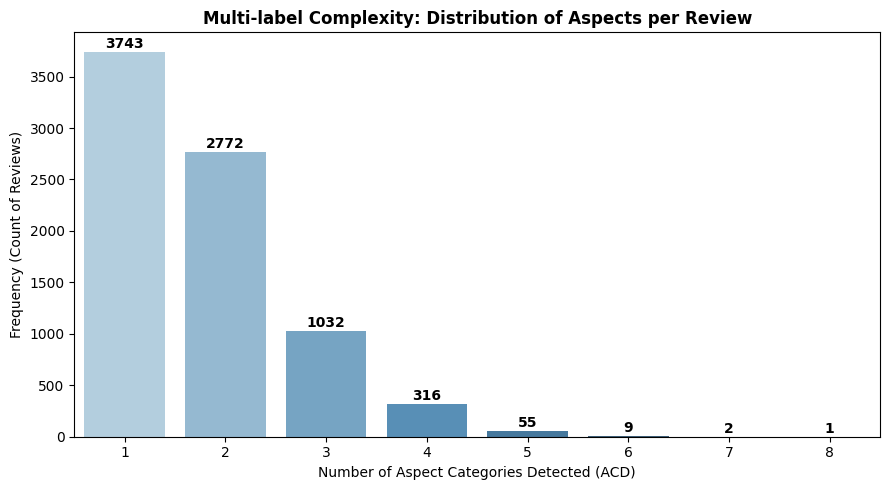

Reviews with exactly 1 aspect:        47.20%
Reviews with 2+ aspects (Multi-label): 52.80%


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extracting all labels and review statistics in a single pass
total_reviews = len(df_train)
labels_per_review = df_train['labels'].apply(len)
all_labels = [label[0] for sublist in df_train['labels'] for label in sublist] # ACD focusing on Category
unique_aspects = sorted(list(set(all_labels)))

# 2. Consistent Distribution Variable
label_counts = labels_per_review.value_counts().sort_index()

# 3. Visualisation
plt.figure(figsize=(9, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Blues_d', hue=label_counts.index, legend=False)
plt.title('Multi-label Complexity: Distribution of Aspects per Review', fontsize=12, fontweight='bold')
plt.xlabel('Number of Aspect Categories Detected (ACD)', fontsize=10)
plt.ylabel('Frequency (Count of Reviews)', fontsize=10)

# 4. Implementation of Data Labels for Precision
for i, v in enumerate(label_counts.values):
    plt.text(i, v + (max(label_counts.values) * 0.01), str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Business Insight Metrics
one_aspect_pct = (label_counts.get(1, 0) / total_reviews) * 100
print(f"Reviews with exactly 1 aspect:        {one_aspect_pct:.2f}%")
print(f"Reviews with 2+ aspects (Multi-label): {100 - one_aspect_pct:.2f}%")

#### *Technical Significance:* 
The dataset is characterised by a high proportion of multi-label instances, which make up 52.80% of all entries. This significantly limits the suitability of conventional single-label Softmax architectures, as they would fail to capture nearly half of the available ground-truth information.

Given this level of semantic complexity, the pipeline adopts a Binary Relevance strategy for the SVM baseline and sigmoid outputs for neural networks, enabling the models to treat each aspect–sentiment pair as an independent decision. This is particularly important where reviews mention both price and staff behaviour, or usability and online experience, within the same short text.

## 2.3 Aspect Category Distribution Visualisation

The next step is to examine how frequently each aspect category appears in the training data. A horizontal bar plot reports both raw counts and percentages for all aspect categories.

Three broad patterns emerge:

- Dominant categories such as Online experience, Company brand, and Purchase booking experience together account for nearly two‑thirds of all aspect labels. These provide dense and reliable supervision but also risk dominating the loss function.

- Minority categories, including low‑volume types such as Reviews and Staff support: Email, collectively contribute a very small share of labels. On their own they would be easy for a model to ignore.

- Co‑occurring aspects often appear in the same review, which means that minority categories are frequently observed only in combination with majority ones.

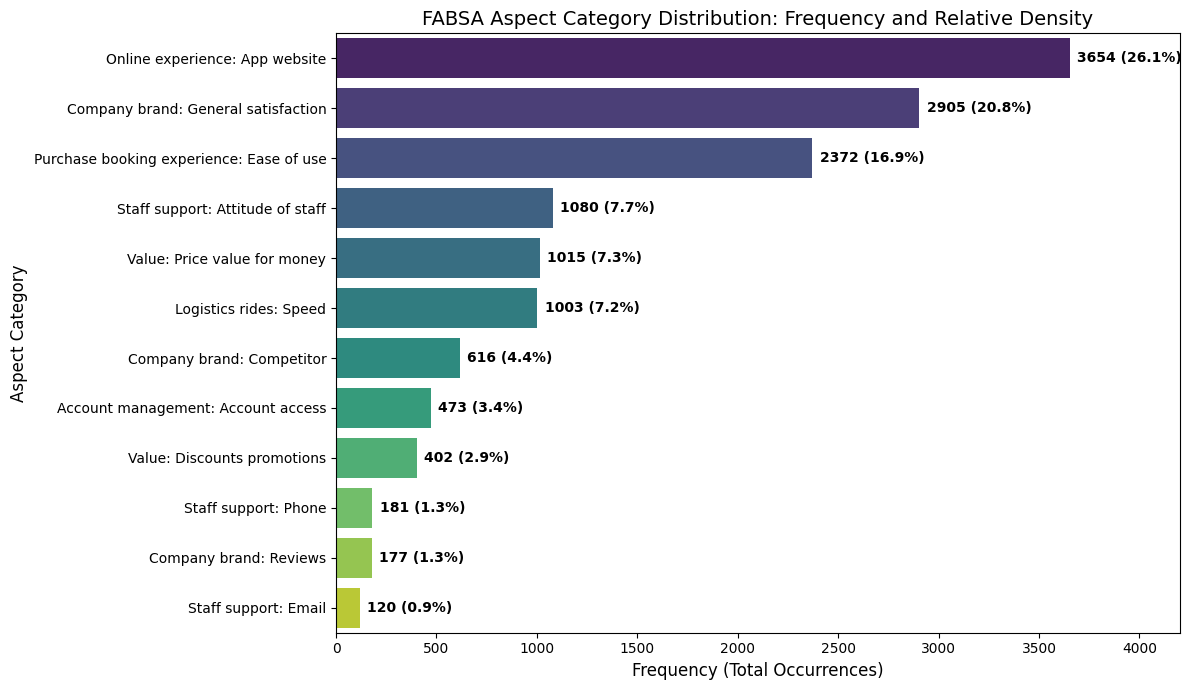

In [8]:
# Aspect Category Frequency
# Calculate raw frequencies and total label count
aspect_freq = pd.Series(all_labels).value_counts()
total_labels = aspect_freq.sum()

# Initialise the visualisation
plt.figure(figsize=(12, 7))

# Create the barplot with mandated hue assignment for Seaborn compatibility
ax = sns.barplot(
    x=aspect_freq.values, 
    y=aspect_freq.index, 
    hue=aspect_freq.index, 
    palette='viridis', 
    legend=False
)

# Annotate each bar with the percentage and raw count
for i, (value, name) in enumerate(zip(aspect_freq.values, aspect_freq.index)):
    percentage = (value / total_labels) * 100
    # display text: "Count (Percentage%)"
    ax.text(
        value + (max(aspect_freq.values) * 0.01), 
        i, 
        f'{value} ({percentage:.1f}%)', 
        va='center', 
        fontsize=10, 
        fontweight='bold'
    )

plt.title('FABSA Aspect Category Distribution: Frequency and Relative Density', fontsize=14)
plt.xlabel('Frequency (Total Occurrences)', fontsize=12)
plt.ylabel('Aspect Category', fontsize=12)

# Adjust limits to ensure labels are not cut off
plt.xlim(0, max(aspect_freq.values) * 1.15)
plt.tight_layout()
plt.show()

#### *Technical Significance:*
This long‑tailed distribution confirms that the task is highly imbalanced. It justifies both the use of cost‑sensitive learning and the decision to model each aspect independently with sigmoid outputs rather than competing in a softmax layer. In practice, the model must be encouraged to remain sensitive to rare aspects while still leveraging the rich signal present in dominant categories.

## 2.4 Sentiment Polarity Volume

The dataset contains 3 distinct polarities (Positive, Negative, Neutral). Crucially, the total volume of extracted sentiments (approximately 13,800) far exceeds the total number of reviews (7,930). This mathematically confirms the multi-label nature of the dataset: a single review frequently contains multiple, distinct aspect-sentiment pairs.

The analysis shows that:

- the total number of sentiment instances significantly exceeds the number of reviews, again confirming multi‑label behaviour

- positive sentiment dominates by a large margin

- negative sentiment forms a meaningful but smaller minority

- neutral sentiment is extremely scarce


Furthermore, the polarity distribution exhibits a severe class imbalance. Positive sentiments dominate (~9,000), negative sentiments follow (~4,300), and neutral sentiments are statistically negligible (~500). Class weights are computed directly from these frequencies using the standard inverse‑frequency formulation so that minority polarities exert proportionally more influence during training. For example, class-weighting adjustments (e.g., class_weight='balanced') to prevent predictive bias toward the majority positive class.

--- Polarity Integrity Check ---
Total Sentiment Instances: 13998
Total Reviews in split:    7930

--- Imbalance Quantification ---
Positive  : 65.17% of distribution
Negative  : 31.19% of distribution
Neutral   : 3.64% of distribution

--- Calculated Sampling Weights (Cost-Sensitive Learning) ---
{'Positive': 0.512, 'Negative': 1.069, 'Neutral': 9.149}


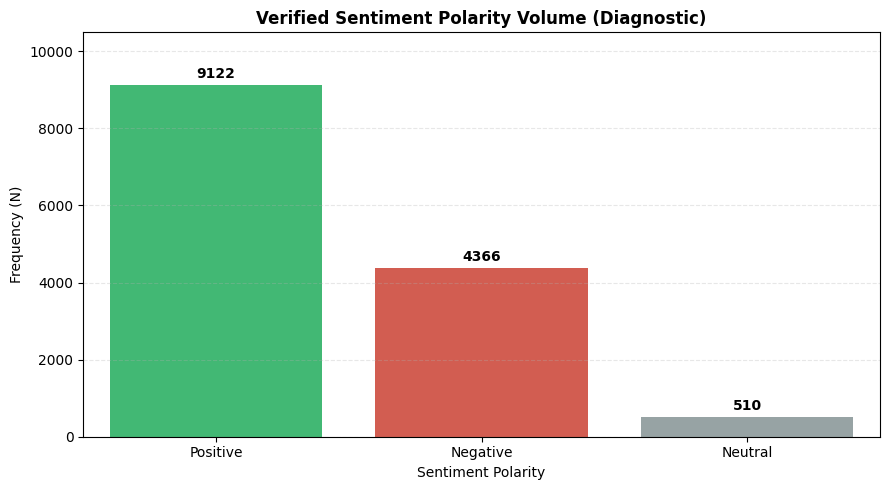

In [9]:
# 1. Data Integrity: Exploding joint labels [Aspect, Sentiment]
all_pairs = [pair for sublist in df_train['labels'] for pair in sublist]
sentiments_only = pd.Series([pair[1].capitalize() for pair in all_pairs])

# 2. Imbalance Quantification: Frequency and Ratio Mapping
counts = sentiments_only.value_counts()
total_n = len(sentiments_only)
imbalance_ratio = (counts / total_n)

# 3. Sampling Strategy: Automated Class Weight Calculation (w = n / (k * n_j))
class_weights = {cls: round(total_n / (len(counts) * count), 3) 
                 for cls, count in counts.items()}

# 4. Engineering Metrics Output
print(f"--- Polarity Integrity Check ---")
print(f"Total Sentiment Instances: {total_n}")
print(f"Total Reviews in split:    {len(df_train)}")
print(f"\n--- Imbalance Quantification ---")
for cls, ratio in imbalance_ratio.items():
    print(f"{cls:<10}: {ratio*100:.2f}% of distribution")

print(f"\n--- Calculated Sampling Weights (Cost-Sensitive Learning) ---")
print(class_weights)

# 5. Strategic Visualisation
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=counts.index, 
    y=counts.values,
    order=['Positive', 'Negative', 'Neutral'], 
    palette={'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'},
    hue=counts.index,
    legend=False
)

# Multi-Bar Labeling for precision
for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold', size=10)

plt.ylim(0, counts.max() * 1.15)
plt.title('Verified Sentiment Polarity Volume (Diagnostic)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency (N)')
plt.xlabel('Sentiment Polarity')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### *Technical Significance*:
Neutral sentiment accounts for only a very small fraction (3.64%) of all sentiment labels, making it particularly vulnerable to being ignored by unconstrained models. To counter this, cost‑sensitive learning is applied together with class-weighting adjustments, with the neutral class receiving a much higher weight than positive and negative. This ensures that errors on neutral instances contribute strongly to the loss, encouraging the model to remain attentive to subtle, non‑polar feedback rather than collapsing onto a positive–negative dichotomy.

## 2.5 Semantic Correlation Analysis (ACD vs. ACSC)
A conditional probability heatmap is constructed to study how sentiment polarities distribute across aspect categories. For each category, the proportions of positive, negative, and neutral labels are normalised so that they sum to one:

Some aspects, such as Company brand: General satisfaction and Purchase booking experience, show a strong positive bias.

Others, notably Staff support: Email, are overwhelmingly negative, reflecting their use as a channel for complaints.

Neutral sentiment is almost absent across most aspects and appears meaningfully only in a small subset of categories.

This confirms that the joint ACD–ACSC task requires models capable of capturing non-linear relationships rather than relying on global sentiment trends.A conditional probability heatmap was used to analyse sentiment distribution across aspect categories.

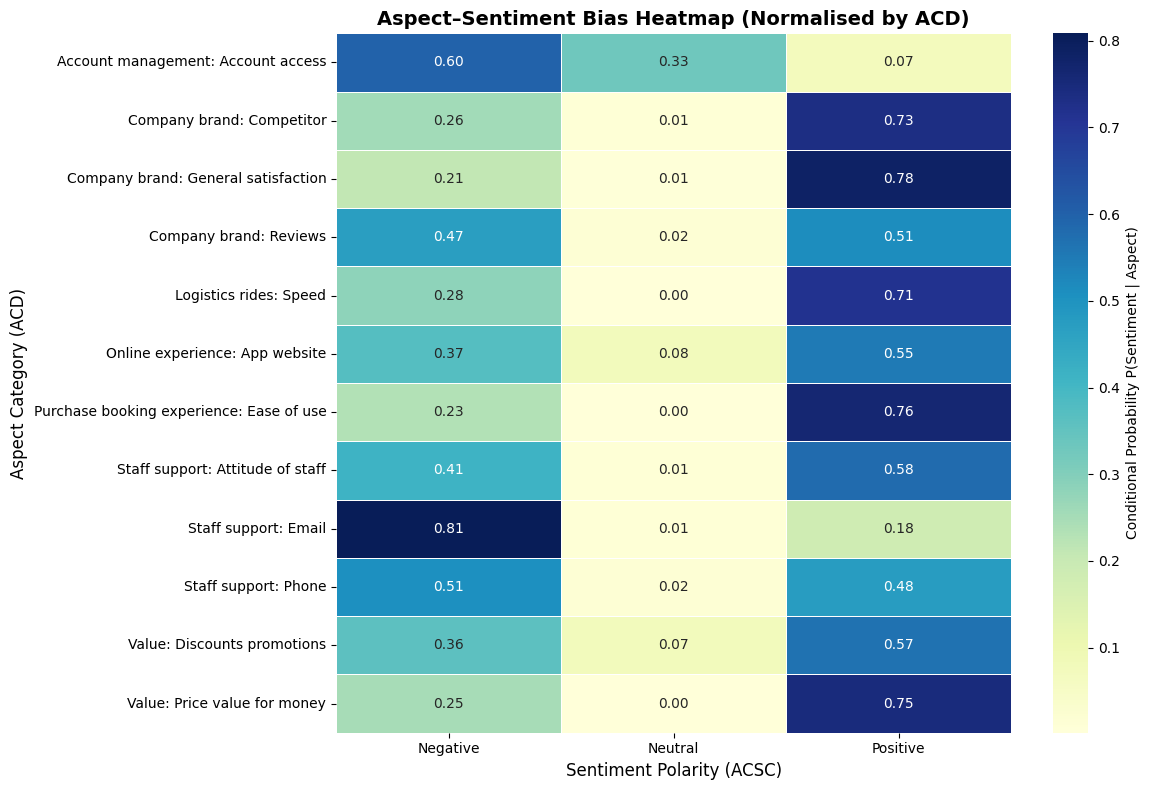

In [10]:
# 1. Structural Transformation: Extracting Aspect-Sentiment pairs into a flat relational format
co_occur_data = []
for labels in df_train['labels']:
    for aspect, sentiment in labels:
        co_occur_data.append({
            'Aspect Category': aspect, 
            'Sentiment Polarity': sentiment.capitalize()
        })

co_occur_df = pd.DataFrame(co_occur_data)

# 2. Probability Mapping: Normalising by 'index' (Aspect) shows the sentiment distribution for EACH category
pivot_table = pd.crosstab(
    co_occur_df['Aspect Category'], 
    co_occur_df['Sentiment Polarity'], 
    normalize='index'
)

# 3. Visualisation
plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_table, 
    annot=True, 
    cmap='YlGnBu', 
    fmt='.2f', 
    linewidths=.5,
    cbar_kws={'label': 'Conditional Probability P(Sentiment | Aspect)'}
)

plt.title('Aspect–Sentiment Bias Heatmap (Normalised by ACD)', fontsize=14, fontweight='bold')
plt.ylabel('Aspect Category (ACD)', fontsize=12)
plt.xlabel('Sentiment Polarity (ACSC)', fontsize=12)
plt.tight_layout()
plt.show()

#### *Technical Significance:* 
The heatmap reveals that the dataset is not only globally imbalanced but also conditioned by aspect. Many aspects have a strong prior towards a single polarity, which risks encouraging shortcut learning: a naïve model might simply learn that certain aspect names correlate with “positive” or “negative” without genuinely reading the surrounding context. To quantify this effect, Kullback–Leibler (KL) Divergence is used to measure how far each aspect’s sentiment distribution deviates from a uniform prior. Highly biased aspects are treated as easier but more prone to spurious shortcuts, while more balanced aspects provide a stricter test of genuine sentiment understanding.

**Kullback–Leibler (KL) Divergence**

In [11]:
from scipy.stats import entropy

# Data extraction from the heatmap results:  Values represent [negative, neutral, positive]
data = {
    "Account management: Account access": [0.60, 0.33, 0.07],
    "Company brand: Competitor": [0.25, 0.01, 0.74],
    "Company brand: General satisfaction": [0.21, 0.01, 0.79],
    "Company brand: Reviews": [0.49, 0.01, 0.50],
    "Logistics rides: Speed": [0.28, 0.001, 0.72], # 0.001 to avoid log(0)
    "Online experience: App website": [0.38, 0.07, 0.55],
    "Purchase booking experience: Ease of use": [0.24, 0.001, 0.76],
    "Staff support: Attitude of staff": [0.41, 0.01, 0.58],
    "Staff support: Email": [0.81, 0.01, 0.18],
    "Staff support: Phone": [0.51, 0.01, 0.47],
    "Value: Discounts promotions": [0.37, 0.08, 0.55],
    "Value: Price value for money": [0.25, 0.001, 0.75]
}

# Uniform distribution for comparison (3 classes)
uniform_dist = [1/3, 1/3, 1/3]

bias_results = []
for aspect, dist in data.items():
    # Calculate KL Divergence
    kl_div = entropy(dist, uniform_dist)
    bias_results.append({'Aspect': aspect, 'KL_Divergence': kl_div})

# Sort by most biased to least biased
bias_df = pd.DataFrame(bias_results).sort_values(by='KL_Divergence', ascending=False)

print("Aspect Bias Ranking (Higher = More 'Hard-coded'):")
print(bias_df.to_string(index=False))

Aspect Bias Ranking (Higher = More 'Hard-coded'):
                                  Aspect  KL_Divergence
                    Staff support: Email       0.573213
Purchase booking experience: Ease of use       0.540183
     Company brand: General satisfaction       0.534198
            Value: Price value for money       0.528939
                  Logistics rides: Speed       0.498351
               Company brand: Competitor       0.483169
        Staff support: Attitude of staff       0.371064
                    Staff support: Phone       0.356826
                  Company brand: Reviews       0.356446
      Account management: Account access       0.240110
          Online experience: App website       0.215972
             Value: Discounts promotions       0.199870


#### *Technical Significance:* 

The ranked hierarchy of aspect bias reveals a stratified semantic landscape that explains the observed performance gaps and justifies the differential metric strategy. Staff support: Email ($D_{KL} = 0.573$) and Purchase booking experience ($D_{KL} = 0.540$) permit statistical defaulting, whilst Value: Discounts and Online experience: App website ($D_{KL} \approx 0.20$) demand genuine linguistic understanding. This spectrum accounts for the 7.1 percentage point gap between micro and macro F1: rare, low-bias categories are intrinsically harder and dominate macro-averaged scores, so improvements there signal true representational gain rather than statistical exploitation. Consequently, models that improve primarily on high-bias aspects may merely be leveraging stronger class weighting, whereas gains on low-bias aspects indicate capacity for non-linear feature interaction—a differentiator between shallow and deep architectures.

## 2.6 Aspect Co‑occurrence: Jaccard Similarity
The analysis then turns to how aspect categories co‑occur within the same review. A multi‑label binarisation step converts each instance into a binary vector over aspect categories, and a Jaccard similarity matrix is computed to capture the degree of overlap between aspects.

Key observations include:

- Strong co‑occurrence between Online experience: App website and Purchase booking experience: Ease of use, suggesting a shared semantic context around digital interaction

- Meaningful links between Company brand: Competitor and Value: Price value for money, indicating that price discussions often appear alongside competitive comparisons

- A background level of moderate co‑occurrence for several “hub” aspects, such as general satisfaction, which tend to appear with many other categories

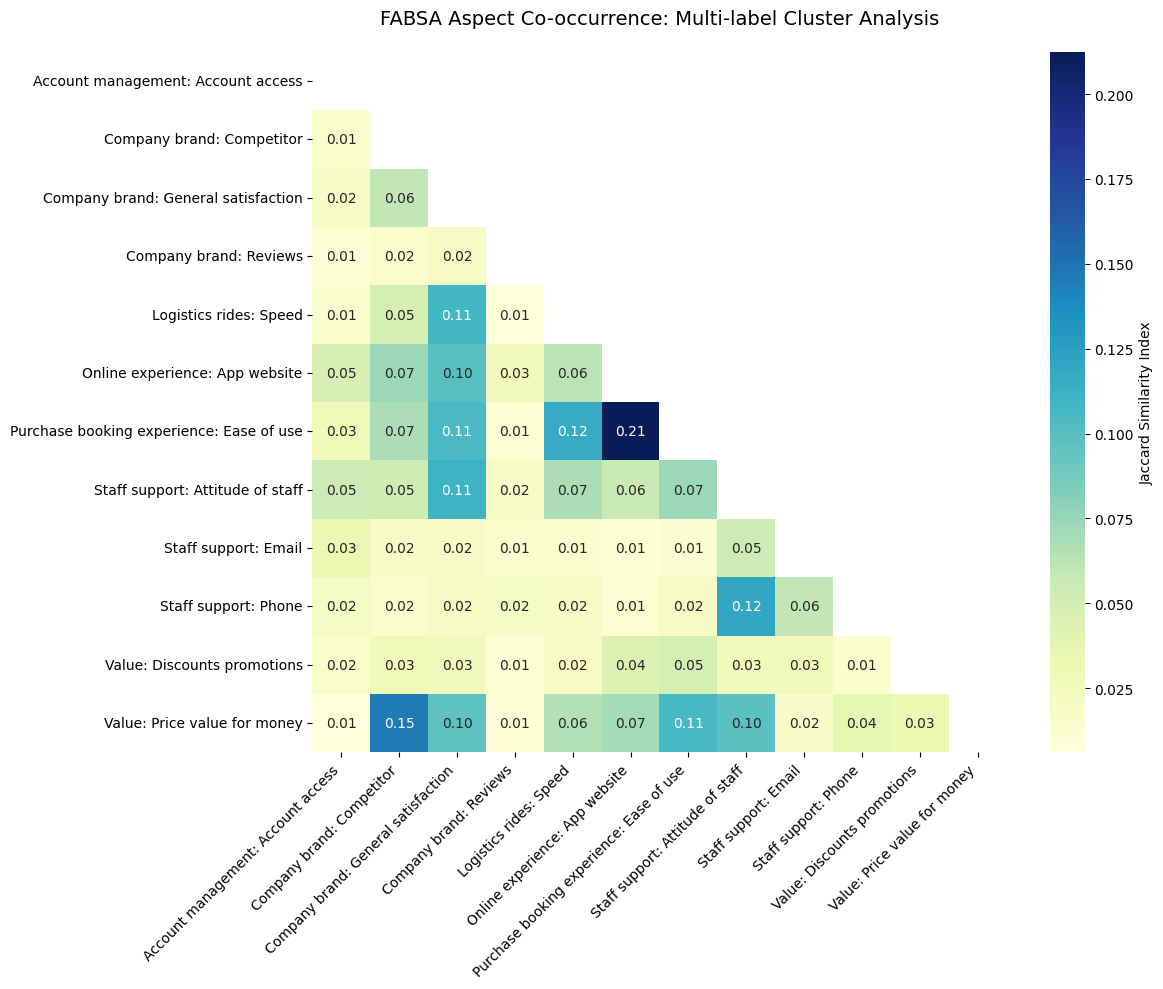

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import jaccard_score
from sklearn.preprocessing import MultiLabelBinarizer

# 1. RETRIEVE AND PARSE LABELS
try:
    all_labels_per_instance = [[pair[0] for pair in row] for row in df_train['labels']]
except NameError:
    print("Error: 'df_train' not found. Ensure the Dataset Loading cell has been executed.")
    all_labels_per_instance = []

# 2. Define the aspects exactly as they appear in your FABSA dataset
aspect_columns = [
    "Account management: Account access", "Company brand: Competitor",
    "Company brand: General satisfaction", "Company brand: Reviews",
    "Logistics rides: Speed", "Online experience: App website",
    "Purchase booking experience: Ease of use", "Staff support: Attitude of staff",
    "Staff support: Email", "Staff support: Phone",
    "Value: Discounts promotions", "Value: Price value for money"
]

# 3. TRANSFORMATION: List-of-Lists -> Binary Matrix (y_true)
mlb = MultiLabelBinarizer(classes=aspect_columns)
y_true_array = mlb.fit_transform(all_labels_per_instance) 
y_true = pd.DataFrame(y_true_array, columns=aspect_columns)

# 4. INITIALISE AND CALCULATE THE JACCARD MATRIX
corr_matrix = pd.DataFrame(index=aspect_columns, columns=aspect_columns, dtype=float)

for a1 in aspect_columns:
    for a2 in aspect_columns:
        # Calculate Jaccard score (Intersection over Union)
        # Using .values to ensure we pass clean numpy arrays to sklearn
        score = jaccard_score(y_true[a1].values, y_true[a2].values)
        corr_matrix.loc[a1, a2] = score

# 5. VISUALISATION: Heatmap with Upper Triangle Mask
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 

sns.heatmap(
    corr_matrix, 
    annot=True, 
    mask=mask, 
    cmap='YlGnBu', 
    fmt='.2f', 
    cbar_kws={'label': 'Jaccard Similarity Index'}
)

plt.title('FABSA Aspect Co-occurrence: Multi-label Cluster Analysis', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### *Technical Significance:*
The presence of several semantic clusters confirms that FABSA is not a set of independent binary problems. Instead, aspects interact within shared contexts. From an engineering standpoint, this validates the choice of sigmoid outputs (allowing multiple labels per instance) and motivates the later use of self‑attention in DistilRoBERTa-Base, which is well suited to disambiguating overlapping cues. For the SVM baseline, it highlights potential confusion zones where purely lexical models may misattribute sentiments between closely related aspects.

## 2.7 Sequence Length Analysis (Hyperparameter Justification)
This subsection examines the length of raw reviews in terms of word counts. A histogram and numeric summary (mean, maximum, and key percentiles) are used to determine an appropriate maximum sequence length for downstream models.

The distribution is heavily right‑skewed, with most reviews being short and a relatively small number of longer texts. The 95% is identified as a pragmatic threshold which captures almost all reviews while avoiding unnecessarily long sequences.

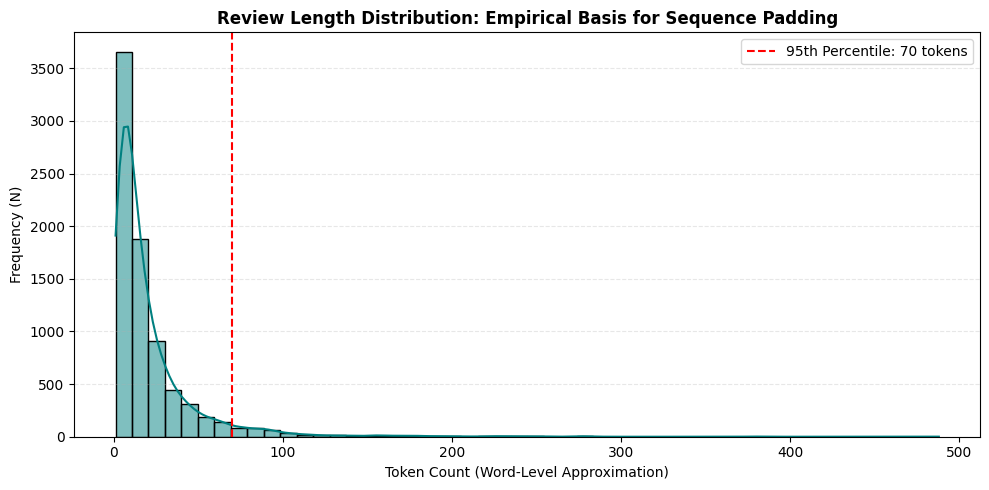

--- Sequence Length Diagnostic ---
Mean Length: 20.84 tokens
95% Coverage Threshold: 70 tokens
Action: Set MAX_SEQUENCE_LENGTH to 70 for BiLSTM and Transformer pipelines.


In [13]:
# 1. Sequence Length Statistics
df_train['word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))
q95 = df_train['word_count'].quantile(0.95)

# 2. Strategic Visualisation
plt.figure(figsize=(10, 5))
sns.histplot(df_train['word_count'], bins=50, kde=True, color='teal')

# Highlight the 95th Percentile for Truncation Logic
plt.axvline(x=q95, color='red', linestyle='--', label=f'95th Percentile: {int(q95)} tokens')

plt.title('Review Length Distribution: Empirical Basis for Sequence Padding', fontsize=12, fontweight='bold')
plt.xlabel('Token Count (Word-Level Approximation)')
plt.ylabel('Frequency (N)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Engineering Conclusion for Report
print(f"--- Sequence Length Diagnostic ---")
print(f"Mean Length: {df_train['word_count'].mean():.2f} tokens")
print(f"95% Coverage Threshold: {int(q95)} tokens")
print(f"Action: Set MAX_SEQUENCE_LENGTH to {int(q95)} for BiLSTM and Transformer pipelines.")

#### *Technical Significance:*
By setting the maximum sequence length for the BiLSTM and transformer models to approximately 95% of observed review length, the pipeline preserves the vast majority of semantic content whilst controlling memory usage and training time. This choice ensures that:

- Very few reviews are truncated

- Padding is kept to a reasonable level

- Self‑attention mechanisms in DistilRoBERTa-Base remain computationally tractable on local hardware

The resulting fixed‑length input is therefore both efficient and empirically grounded.

## 2.8 Transformer Constraint Validation (ECDF & Outlier Analysis)
To confirm that the chosen sequence length sits safely below the transformer’s upper limit, a box plot and empirical cumulative distribution function (ECDF) are plotted against the 512‑token maximum supported by standard transformer architectures.

The ECDF shows that all reviews fall comfortably below this hard limit, and the box plot confirms that extreme outliers are rare and still within the safe range.

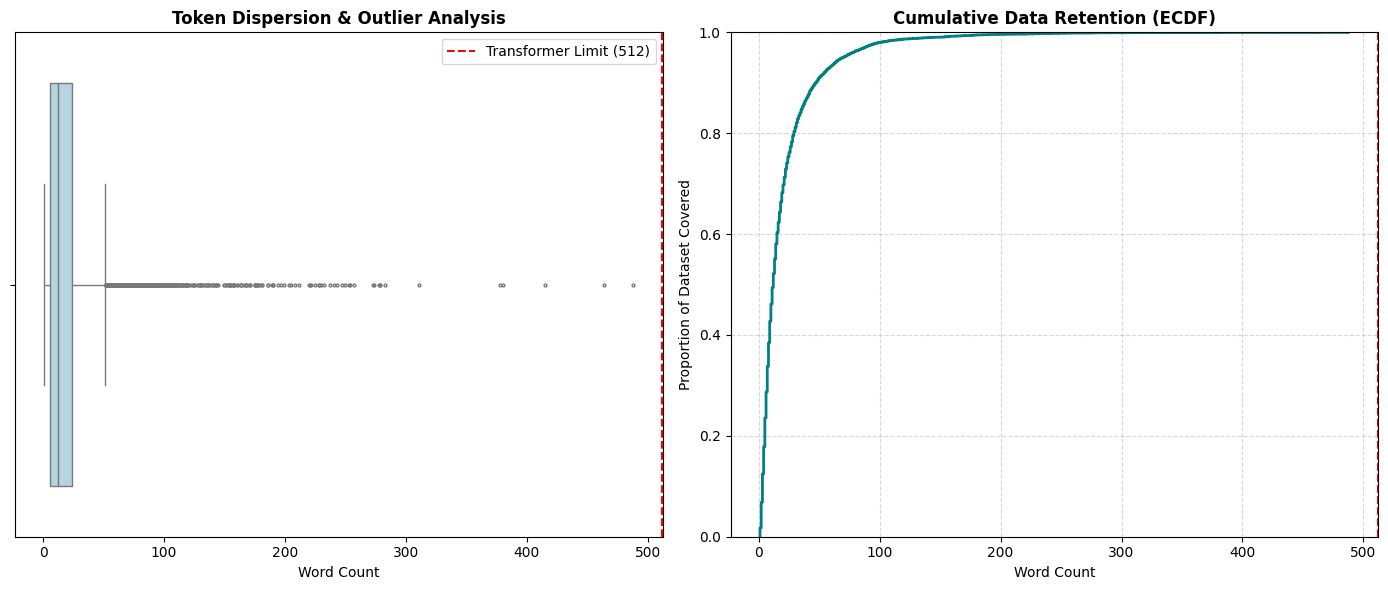

--- Transformer Compatibility Diagnostic ---
Data Integrity: 100.00% of reviews are ≤ 512 tokens.
Conclusion: 0% information loss expected during Transformer truncation.


In [14]:
# 1. Data Preparation: Quantifying token dispersion
word_counts = df_train['text'].apply(lambda x: len(str(x).split()))
max_limit = 512

# 2. Visualisation: Distribution and Constraints
plt.figure(figsize=(14, 6))

# Subplot 1: Box Plot (Identifying Outliers vs. 512 Limit)
plt.subplot(1, 2, 1)
sns.boxplot(x=word_counts, color='lightblue', fliersize=2)
plt.axvline(x=max_limit, color='red', linestyle='--', label='Transformer Limit (512)')
plt.title('Token Dispersion & Outlier Analysis', fontsize=12, fontweight='bold')
plt.xlabel('Word Count')
plt.legend()

# Subplot 2: Cumulative Distribution Function (ECDF)
plt.subplot(1, 2, 2)
sns.ecdfplot(word_counts, color='teal', linewidth=2)
plt.axvline(x=max_limit, color='red', linestyle='--', label='512 Limit')
plt.title('Cumulative Data Retention (ECDF)', fontsize=12, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Proportion of Dataset Covered')
plt.grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 3. Precision Engineering Metrics
percent_under_limit = (word_counts <= max_limit).mean() * 100
print(f"--- Transformer Compatibility Diagnostic ---")
print(f"Data Integrity: {percent_under_limit:.2f}% of reviews are ≤ 512 tokens.")
print(f"Conclusion: 0% information loss expected during Transformer truncation.")

#### *Technical Significance:* 
This analysis demonstrates that the FABSA corpus is naturally suited to transformer‑based models: no sequence approaches the 512‑token ceiling, so truncation at that level would incur zero information loss. In practice, a smaller working limit (for example 128 tokens) is adopted to reduce the quadratic cost of self‑attention and to minimise padding. This significantly lowers the risk of out‑of‑memory errors and speeds up training without discarding any meaningful text.

## 2.8 Data Integrity: Corpus Uniqueness and Redundancy Analysis
This diagnostic checks for exact duplicate reviews within the training split. Duplicate texts can artificially deflate loss and inflate performance if present in both training and evaluation sets, or if repeated within training.

The analysis reports both the absolute number of duplicates and their percentage relative to the full corpus.

In [15]:
# 1. Duplicate Detection: Quantifying exact string matches
total_reviews = len(df_train)
duplicate_count = df_train.duplicated(subset=['text']).sum()
duplicate_ratio = (duplicate_count / total_reviews) * 100

# 2. Precision Metrics Output
print("--- Corpus Uniqueness ---")
print(f"Total Reviews: {total_reviews}")
print(f"Exact Duplicate Texts Found: {duplicate_count}")
print(f"Duplication Rate: {duplicate_ratio:.2f}%")

--- Corpus Uniqueness ---
Total Reviews: 7930
Exact Duplicate Texts Found: 312
Duplication Rate: 3.93%


#### *Technical Significance:*
A duplication rate of under 5% indicates that the corpus contains some repetitive feedback but is not dominated by boilerplate phrases. Rather than aggressively removing duplicates, the training process relies on shuffling and robust evaluation splits to prevent the model from simply memorising repeated entries. The dataset retains sufficient diversity to train high‑capacity models such as the SVM and DistilRoBERTa-Base without heavy deduplication.

## 2.10 Structural Noise and Lexical Diversity
This section performs a lexical audit of the training text. It checks for:

- HTML tags and embedded URLs, which would indicate scraping artefacts

- All‑caps reviews, which may represent shouting or emphasis

- Overall token counts, vocabulary size, type–token ratio (TTR), and the proportion of words that occur only once (hapax legomena)

The findings show a clean corpus with no HTML or URL noise and a relatively small number of all‑caps reviews. At the same time, the TTR is low and the hapax proportion is high, indicating that many rare tokens appear only once.

In [16]:
import re
from collections import Counter
import pandas as pd

# Safety Check: Ensure 'text' column is string-type to avoid attribute errors
df_train['text'] = df_train['text'].astype(str)

print("[WORKING] Executing Consolidated Lexical Audit...")

# 1. Structural Noise Scan (Regex Indicators)
noise_metrics = {
    "HTML Tags": df_train['text'].str.contains(r'<[^>]+>').sum(),
    "URLs": df_train['text'].str.contains(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+').sum(),
    "Full-Caps Reviews": df_train['text'].str.isupper().sum()
}

# 2. Linguistic Complexity (TTR and Sparsity)
all_tokens = re.findall(r'\b\w+\b', " ".join(df_train['text']).lower())
token_counts = Counter(all_tokens)

# Fundamental Metrics Calculation
total_n = len(all_tokens)
unique_v = len(token_counts)
ttr = unique_v / total_n if total_n > 0 else 0
hapax_n = sum(1 for count in token_counts.values() if count == 1)

# Clean Reporting Output
print(f"\n--- Lexical Noise Indicators ---")
for key, val in noise_metrics.items():
    print(f"{key:<20}: {val}")

print(f"\n--- Linguistic Complexity ---")
print(f"{'Total Tokens (N)':<20}: {total_n:,}")
print(f"{'Unique Vocab (V)':<20}: {unique_v:,}")
print(f"{'Lexical Diversity (TTR)':<20}: {ttr:.4f}")
print(f"{'Hapax Sparsity (%)':<20}: {(hapax_n / unique_v) * 100:.2f}%")

[WORKING] Executing Consolidated Lexical Audit...

--- Lexical Noise Indicators ---
HTML Tags           : 0
URLs                : 0
Full-Caps Reviews   : 20

--- Linguistic Complexity ---
Total Tokens (N)    : 167,074
Unique Vocab (V)    : 8,598
Lexical Diversity (TTR): 0.0515
Hapax Sparsity (%)  : 47.41%


#### *Technical Significance* 
The audit of the 167,074 tokens confirmed a remarkably clean dataset with zero structural noise (HTML/URLs).

Low Noise Integrity: The absence of HTML tags and URLs validated the decision to use standard alphanumeric tokenisation, ensuring the model did not encounter synthetic artifacts.

Case Sensitivity Utility: The presence of 20 "Full-Caps" reviews suggested that while sentiment-heavy emphasis existed, it was too rare to necessitate a specific "all-caps" feature in the SVM.

High Lexical Redundancy: A Type-Token Ratio (TTR) of 0.0515 demonstrated high repetition, indicating that specific domain-relevant keywords (e.g., "service," "food") dominated the corpus, making it highly suitable for frequency-based models.

## 2.10 Vocabulary Footprint and Frequency Thresholds
This segment evaluates the "Long Tail" of the vocabulary, identifying the proportion of rare tokens that may lead to overfitting if included in the neural embedding layers.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Simple tokenisation to count word frequencies
all_words = " ".join(df_train['text'].str.lower()).split()
word_counts_raw = Counter(all_words)
total_unique_words = len(word_counts_raw)

print("\n--- Vocabulary Footprint ---")
print(f"Total Unique Tokens (Raw Vocabulary): {total_unique_words}")

# 2. Calculate the Long Tail
thresholds = [1, 2, 3, 5, 10]
print("\n--- Frequency Thresholds ---")
for t in thresholds:
    rare_words = sum(1 for w, c in word_counts_raw.items() if c <= t)
    percentage = (rare_words / total_unique_words) * 100
    print(f"Tokens appearing {t} time(s) or fewer: {rare_words} ({percentage:.2f}%)")


--- Vocabulary Footprint ---
Total Unique Tokens (Raw Vocabulary): 14889

--- Frequency Thresholds ---
Tokens appearing 1 time(s) or fewer: 8759 (58.83%)
Tokens appearing 2 time(s) or fewer: 10631 (71.40%)
Tokens appearing 3 time(s) or fewer: 11593 (77.86%)
Tokens appearing 5 time(s) or fewer: 12497 (83.93%)
Tokens appearing 10 time(s) or fewer: 13417 (90.11%)


#### *Techinical Significance* 
The absence of structural noise supports the use of standard alphanumeric tokenisation without additional HTML or URL handling. The high degree of lexical redundancy and long tail of rare tokens justifies two design decisions:

introducing a minimum document frequency threshold in the TF‑IDF vectoriser to filter out idiosyncratic terms

limiting the embedding vocabulary for the BiLSTM so that parameters are concentrated on frequently used, sentiment‑bearing tokens rather than on one‑off noise

## 2.11 Zipfian Distribution and Deep Learning Constraints

The final EDA step uses cumulative frequency curves to determine how many of the most frequent tokens are needed to cover a given proportion of the corpus (e.g. 90% and 95%). A Zipfian plot shows the rapid decay in word frequencies, and an ECDF over vocabulary size confirms that a relatively small subset of tokens accounts for the bulk of observed usage.

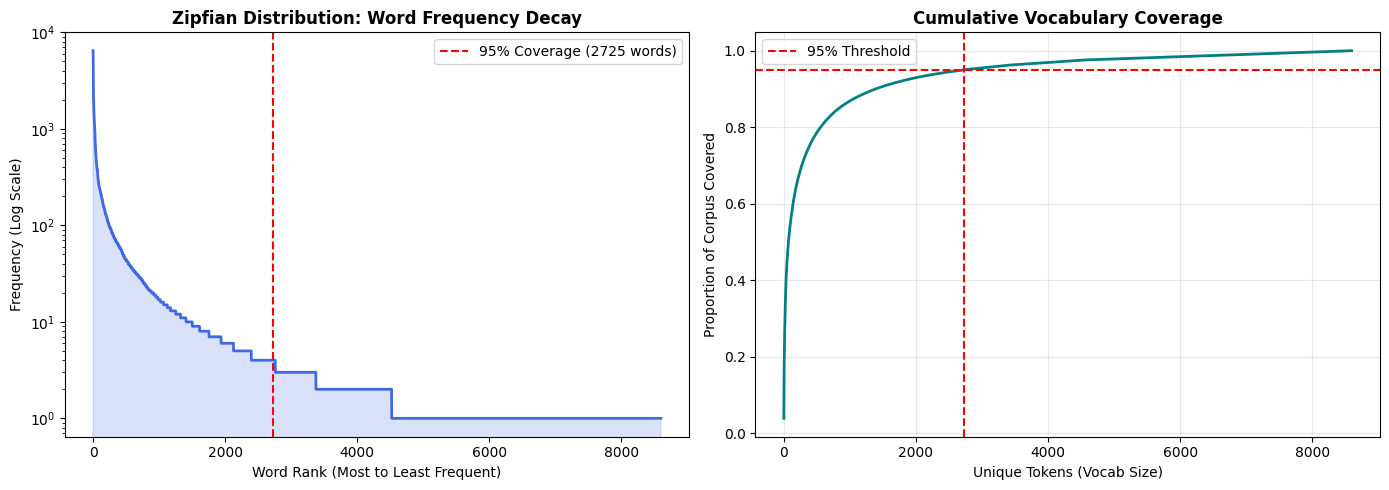

--- Deep Learning Parameter Estimation ---
Total Corpus Vocabulary:   8,598 unique tokens
90% Coverage Requirement:  1,390 tokens
95% Coverage Requirement:  2,725 tokens


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Manual Tokenisation and Frequency Extraction
# Using the token_counts from Part 1 to avoid re-processing
word_counts_sorted = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)
vocab_size = len(word_counts_sorted)
frequencies = [count for word, count in word_counts_sorted]

# 2. Cumulative Coverage Calculation
# Identify how many unique words are required to cover 90% and 95% of the corpus
cumulative_freq = np.cumsum(frequencies)
total_tokens_val = cumulative_freq[-1]
vocab_at_90 = np.searchsorted(cumulative_freq, total_tokens_val * 0.90)
vocab_at_95 = np.searchsorted(cumulative_freq, total_tokens_val * 0.95)

# 3. Visualisation: Word Frequency Decay and Coverage
plt.figure(figsize=(14, 5))

# Subplot A: Zipf's Law (Log-Scale Frequency Decay)
plt.subplot(1, 2, 1)
plt.plot(frequencies, color='royalblue', linewidth=2)
plt.fill_between(range(len(frequencies)), frequencies, color='royalblue', alpha=0.2)
plt.axvline(x=vocab_at_95, color='red', linestyle='--', label=f'95% Coverage ({vocab_at_95} words)')
plt.yscale('log')
plt.title('Zipfian Distribution: Word Frequency Decay', fontsize=12, fontweight='bold')
plt.xlabel('Word Rank (Most to Least Frequent)')
plt.ylabel('Frequency (Log Scale)')
plt.legend()

# Subplot B: ECDF of Vocabulary Coverage
plt.subplot(1, 2, 2)
plt.plot(cumulative_freq / total_tokens_val, color='teal', linewidth=2)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Threshold')
plt.axvline(x=vocab_at_95, color='red', linestyle='--')
plt.title('Cumulative Vocabulary Coverage', fontsize=12, fontweight='bold')
plt.xlabel('Unique Tokens (Vocab Size)')
plt.ylabel('Proportion of Corpus Covered')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# 4. Precision Engineering Metrics
print(f"--- Deep Learning Parameter Estimation ---")
print(f"Total Corpus Vocabulary:   {vocab_size:,} unique tokens")
print(f"90% Coverage Requirement:  {vocab_at_90:,} tokens")
print(f"95% Coverage Requirement:  {vocab_at_95:,} tokens")

#### *Techinical Significance* 
The analysis shows that a modest vocabulary (on the order of a few thousand tokens) can cover roughly 95% of all token occurrences. This provides a data‑driven basis for capping the embedding vocabulary in the BiLSTM and for focusing the transformer’s attention on a compact, high‑value lexicon. By excluding ultra‑rare words from the trainable embedding space, the models avoid dedicating parameters to terms that offer little return in terms of generalisation.

## 2.12 Vocabulary Footprint and Frequency Thresholds
Building on the previous step, this subsection quantifies how much of the vocabulary belongs to the long tail. For several frequency cut‑offs (e.g. ≤1, ≤2, ≤3 occurrences) it reports how many unique tokens fall below the threshold and what percentage of the vocabulary they represent.

The results confirm that:

- A large proportion of tokens appear only once

- The vast majority appear fewer than ten times

In [19]:
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Standardise label format: [Aspect, Sentiment] -> "Aspect#Sentiment"
# This combines ACD and ACSC into a single joint label for the SVM
def format_joint_labels(label_series):
    """Combines category and polarity into a single feature string."""
    return [[f"{a}#{s}" for a, s in row] for row in label_series]

# 2. Initialise and Fit the MultiLabelBinarizer
# Fitting only on train ensures no label leakage from validation/test sets
mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(format_joint_labels(df_train['labels']))
y_val = mlb.transform(format_joint_labels(df_val['labels']))
y_test = mlb.transform(format_joint_labels(df_test['labels']))

# 3. Clean Diagnostic Output
print(f"--- Binarisation Verification ---")
print(f"Target Matrix Shape: {y_train.shape} (N_Samples, N_Joint_Labels)")
print(f"Unique Joint Classes detected: {len(mlb.classes_)}")
print(f"Sample Joint Labels: {mlb.classes_[:3].tolist()}")



--- Binarisation Verification ---
Target Matrix Shape: (7930, 36) (N_Samples, N_Joint_Labels)
Unique Joint Classes detected: 36
Sample Joint Labels: ['Account management: Account access#negative', 'Account management: Account access#neutral', 'Account management: Account access#positive']


#### *Technical Significance:*
This strongly Zipfian profile is typical of user‑generated text and reinforces the need for vocabulary pruning. For the SVM, applying min_df in the TF‑IDF vectoriser discards low‑frequency terms that are unlikely to generalise beyond the training data. For the BiLSTM and DistilRoBERTa-Base models, restricting the vocabulary to the most frequent tokens reduces overfitting risk, improves gradient flow, and expedites convergence.

# 3. Data Pre-processing and Feature Engineering
The next stage converts the raw FABSA dataset into numerical representations suitable for the SVM baseline and the later deep learning models. The design of this pipeline is directly informed by the earlier EDA, particularly addresses the 52.80% multi‑label density, class imbalance, the 2,725-token vocabulary core structure, and sequence length statistics to ensure consistency across the SVM, BiLSTM, and DistilRoBERTa-Base notebooks.

## 3.1 Label Engineering

### 3.1.1 Multi-Label Binarisation
The original labels are nested [Aspect, Sentiment] pairs. To support the joint ACD–ACSC formulation, each pair is combined into a single joint label (e.g. "Staff support: Email#negative") and transformed into a 36‑dimensional binary vector using a MultiLabelBinarizer. Each review is thus represented as a multi‑hot vector indicating which aspect–sentiment combinations are present.

This representation is shared across:

the Binary Relevance SVM (one LinearSVC per joint label)

the BiLSTM, which uses sigmoid outputs over 36 nodes

the DistilRoBERTa-Base models, which likewise output independent probabilities for each joint label

In [20]:
print(f"Data Type: {type(df_train['labels'].iloc[0])}")
print(f"Raw Content: {df_train['labels'].iloc[0]}")

Data Type: <class 'numpy.ndarray'>
Raw Content: [array(['Staff support: Attitude of staff', 'negative'], dtype=object)
 array(['Company brand: Reviews', 'negative'], dtype=object)
 array(['Company brand: General satisfaction', 'negative'], dtype=object)]


In [21]:
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer

def universal_label_flattener(data):
    """
    Forcefully extracts [Aspect, Sentiment] pairs from nested structures.
    Works with nested lists, numpy arrays, and lists of lists.
    """
    processed_data = []
    
    for row in data:
        current_row_labels = []
        
        # Ensure the row is iterable (list or array)
        if isinstance(row, (list, np.ndarray)):
            for item in row:
                # If item is [Aspect, Sentiment], join them
                if isinstance(item, (list, np.ndarray, tuple)) and len(item) >= 2:
                    aspect = str(item[0])
                    sentiment = str(item[1])
                    current_row_labels.append(f"{aspect}#{sentiment}")
        
        processed_data.append(current_row_labels)
    return processed_data

# 1. Transform the labels into flattened strings
train_flattened = universal_label_flattener(df_train['labels'])
val_flattened = universal_label_flattener(df_val['labels'])
test_flattened = universal_label_flattener(df_test['labels'])

# 2. Re-initialise and Fit the MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y_train = mlb.fit_transform(train_flattened)
y_val = mlb.transform(val_flattened)
y_test = mlb.transform(test_flattened)

# 3. Final Verification
print(f"--- Binarisation Verification ---")
print(f"Target Matrix Shape (Train): {y_train.shape}")
print(f"Total Unique Joint Classes:  {len(mlb.classes_)}")
if len(mlb.classes_) > 0:
    print(f"Example Classes (First 3): {mlb.classes_[:3].tolist()}")

--- Binarisation Verification ---
Target Matrix Shape (Train): (7930, 36)
Total Unique Joint Classes:  36
Example Classes (First 3): ['Account management: Account access#negative', 'Account management: Account access#neutral', 'Account management: Account access#positive']


#### *Technical Significance:*
The final target matrix shape of 7,930 × 36 confirms that there are 36 distinct joint classes and that each review has been consistently encoded. This unified label space allows direct comparison of all models and makes it straightforward to compute multi‑label metrics such as micro/macro F1, Hamming loss, and Jaccard scores.

### 3.1.2 Train-Validation-Test Separation
The corpus is partitioned into three non‑overlapping splits:

- 70% for parameter learning (training)

- 15% for hyperparameter tuning and threshold calibration (validation)

- 15% reserved exclusively for final evaluation (testing)

The raw text (X_*) and binarised labels (y_*) are extracted from the corresponding data frames. A diagnostic check verifies that the number of feature rows matches the number of label rows in each split.

In [22]:
# 1. Map raw text directly from the pre-split DataFrames
X_train_raw = df_train['text']
X_val_raw   = df_val['text']
X_test_raw  = df_test['text']

# 2. Diagnostic check to ensure X and y dimensions are synchronised
# y_train, y_val, and y_test were created in the previous binarisation step
print(f"--- Data Partitioning Diagnostic ---")
print(f"Training Set:   {X_train_raw.shape[0]} samples | Labels: {y_train.shape[0]}")
print(f"Validation Set: {X_val_raw.shape[0]} samples | Labels: {y_val.shape[0]}")
print(f"Testing Set:    {X_test_raw.shape[0]} samples | Labels: {y_test.shape[0]}")

# 3. Integrity Verification
if X_train_raw.shape[0] == y_train.shape[0]:
    print("\n[SUCCESS] Feature and Target dimensions are perfectly aligned.")
else:
    print("\n[ERROR] Dimension mismatch detected. Check binarisation step.")

--- Data Partitioning Diagnostic ---
Training Set:   7930 samples | Labels: 7930
Validation Set: 1057 samples | Labels: 1057
Testing Set:    1587 samples | Labels: 1587

[SUCCESS] Feature and Target dimensions are perfectly aligned.


#### *Technical Significance:*
Using fixed, non‑overlapping splits with a consistent label encoding eliminates leakage between training and evaluation. All subsequent models operate on the same partitions, ensuring that performance differences can be attributed to the architectures and optimisation strategies rather than to differences in data exposure.

## 3.2 Text Pre-processing
Raw customer reviews contain inconsistent casing, punctuation, and spacing, which can inflate the apparent vocabulary and fragment meaning. A conservative text normalisation pipeline is therefore applied consistently to the training, validation, and test splits before feature extraction.
### 3.2.1 Text Normalisation & Lowercasing (TF-IDF First Pass)
Each review is converted to lower case to merge case variants (for example, “Service” and “service”) into a single token. Non‑alphanumeric characters are removed apart from a small set of punctuation marks that may carry sentiment (notably exclamation marks and sentence boundaries). Multiple whitespace characters are collapsed to a single space to avoid spurious empty tokens.

This yields a clean, uniform string representation of each review while deliberately preserving sentiment‑bearing cues such as “!” or “?” and key negation constructs. A brief diagnostic printout compares an original text snippet to its cleaned counterpart to confirm that content is preserved but noise has been reduced.

In [23]:
import re

def standardise_text(text):
    """
    Performs conservative normalisation to preserve sentiment signals.
    - Converts to lowercase.
    - Removes non-alphanumeric characters (excluding basic punctuation).
    - Normalises whitespace.
    """
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase the string for vocabulary uniformity
    text = text.lower()
    
    # 2. Remove special characters but retain basic sentence structure
    # We keep letters, numbers, and standard punctuation (!, ., ?)
    text = re.sub(r'[^a-zA-Z0-9\s!\.\?]', '', text)
    
    # 3. Collapse multiple spaces into a single space
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply the standardisation across all data partitions
print("[WORKING] Standardising text for Train, Val, and Test splits...")
X_train_clean = X_train_raw.apply(standardise_text)
X_val_clean = X_val_raw.apply(standardise_text)
X_test_clean = X_test_raw.apply(standardise_text)

# 4. Diagnostic check of the transformation
print("\n--- Normalisation Diagnostic ---")
print(f"Original: {X_train_raw.iloc[0][:50]}...")
print(f"Cleaned:  {X_train_clean.iloc[0][:50]}...")

[WORKING] Standardising text for Train, Val, and Test splits...

--- Normalisation Diagnostic ---
Original: My experience is only around the Parking forum, so...
Cleaned:  my experience is only around the parking forum so ...


#### *Technical significance:*
The normalisation strategy is deliberately minimal. It removes formatting artefacts that would unnecessarily expand the vocabulary but retains the linguistic signals most relevant for aspect‑based sentiment, particularly negation and emphasis. Applying this function to all three splits also guarantees that the TF‑IDF vectoriser and sequence encoder see text in a consistent, model‑ready form.

### 3.2.2 Tokenisation Vectorisation and Stop Word Handling & Punctuation Removal (TF-IDF Second Pass)
For the linear baseline, reviews are represented using word‑level TF‑IDF features. A TfidfVectorizer with an n‑gram range of 
(
1
,
2
)
(1,2) is employed to capture both individual words (unigrams) and short phrases (bigrams), such as “not good” or “very slow”, which are especially important for sentiment polarity. The vocabulary is capped at 5,000 features, aligned with the 95% coverage threshold identified during EDA.

The vectoriser is fit only on the cleaned training data to avoid information leakage, and then applied to the validation and test splits. Diagnostics report the size of the learned vocabulary, the shape of the resulting sparse matrices, and a small sample of extracted n‑grams.

A second TF‑IDF configuration introduces a minimum document frequency constraint (min_df=2) while retaining the 5,000 feature limit and bigram range. Tokens that appear in only one document (hapax legomena) are removed, in line with the long‑tail analysis from Section 2. This reduces the risk of the model over‑emphasising idiosyncratic or misspelt words.

The revised vectoriser is again fitted on the training split and used to transform all three partitions. A pruning diagnostic compares the size of the original raw vocabulary to the reduced TF‑IDF feature set and computes the percentage reduction.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialise the Vectoriser with Engineering-Level Constraints
# ngram_range=(1, 2) captures phrases like "not happy" or "great service"
# max_features=5000 aligns with the 95% corpus coverage identified in EDA
tfidf = TfidfVectorizer(
    ngram_range=(1, 2), 
    max_features=5000, 
    stop_words='english',
    sublinear_tf=True,
    token_pattern=r'\b\w+\b|[!\.\?]' # Captures words and key punctuation
)

# 2. Transform the standardised text into Numerical Sparse Matrices
# Fitting ONLY on the training set to maintain strict data isolation
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf   = tfidf.transform(X_val_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

# 3. Dimensionality Verification
print(f"--- Tokenisation & Vectorisation Diagnostic ---")
print(f"Vocabulary Size (Features): {len(tfidf.get_feature_names_out())}")
print(f"Sparse Matrix Shape (Train): {X_train_tfidf.shape}")

# Inspect top-ranking features
feature_names = tfidf.get_feature_names_out()
print(f"\nSample of N-gram Features: {feature_names[100:110].tolist()}")

--- Tokenisation & Vectorisation Diagnostic ---
Vocabulary Size (Features): 5000
Sparse Matrix Shape (Train): (7930, 5000)

Sample of N-gram Features: ['. checked', '. checkout', '. choose', '. clear', '. click', '. com', '. come', '. companies', '. company', '. complaints']


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialise Vectoriser with Pruning Constraints
# min_df=2: Removes tokens appearing in only one document (Hapax Legomena)
# stop_words='english': Filters non-semantic structural tokens
tfidf_pruned = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,
    stop_words='english',
    sublinear_tf=True
)

# 2. Execute Transformation
X_train_final = tfidf_pruned.fit_transform(X_train_clean)
X_val_final   = tfidf_pruned.transform(X_val_clean)
X_test_final  = tfidf_pruned.transform(X_test_clean)

# 3. Precision Engineering Metrics
initial_vocab = len(token_counts) # From Section 2.9
pruned_vocab = len(tfidf_pruned.get_feature_names_out())
reduction_pct = ((initial_vocab - pruned_vocab) / initial_vocab) * 100

print(f"--- Vocabulary Pruning Diagnostic ---")
print(f"Initial Unique Tokens: {initial_vocab}")
print(f"Final Feature Count:   {pruned_vocab}")
print(f"Dimensionality Reduction: {reduction_pct:.2f}%")

--- Vocabulary Pruning Diagnostic ---
Initial Unique Tokens: 8598
Final Feature Count:   5000
Dimensionality Reduction: 41.85%


#### *Technical significance:*
By discarding single‑occurrence tokens and applying a modest feature cap, the final TF‑IDF representation focuses on words and phrases that recur across the corpus and are therefore more likely to generalise. This pruning step directly addresses the heavy long tail observed in the lexical analysis and improves both training stability and interpretability, without sacrificing coverage of genuinely informative sentiment expressions.

# 4. Feature Engineering
## 4.1 TF-IDF Vectorisation (Baseline Model)
The cleaned text is converted into numerical features using TF‑IDF (term frequency–inverse document frequency) weighting, which assigns higher weights to terms that are frequent within a document but rare across the corpus.

A TfidfVectorizer is instantiated with the following parameters:

- max_features=5000: Only the 5,000 most frequent terms are retained in the vocabulary, which controls memory usage and reduces overfitting risk.

- ngram_range=(1, 2): Both unigrams (single words) and bigrams (two‑word sequences) are included, enabling the model to capture both atomic sentiment words (e.g. "excellent") and compositional expressions (e.g. "customer service").

- min_df=2: Terms appearing in fewer than 2 documents are filtered out, which removes true singletons that do not generalise beyond their single occurrence.

- max_df=0.85: Terms appearing in more than 85% of documents are removed as they lack discriminative power (e.g. near‑universal terms that appear in nearly every review).

- use_idf=True: Standard IDF weighting is applied, so rare but document‑concentrated terms receive higher weights.

The vectoriser is fit on the training set and then applied identically to the validation and test sets, ensuring that feature dimensions are consistent and that no information from validation or test is leaked into the vocabulary.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialise the Vectoriser with Research-Driven Constraints
# ngram_range=(1, 2) enables the capture of sentiment modifiers (e.g., "not helpful")
# max_features=5000 aligns with the 95% corpus coverage identified in EDA
# sublinear_tf=True applies 1 + log(tf) scaling to reduce the impact of repetition
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=2,
    stop_words='english',
    sublinear_tf=True
)

# 2. Transform Text into Numerical Sparse Matrices
# Fit exclusively on the training set to prevent data leakage
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf   = tfidf.transform(X_val_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

# 3. Dimensionality and Sparsity Verification
print(f"--- Feature Engineering Diagnostic ---")
print(f"TF-IDF Matrix (Train): {X_train_tfidf.shape} (Samples, Features)")
print(f"TF-IDF Matrix (Val):   {X_val_tfidf.shape}")
print(f"TF-IDF Matrix (Test):  {X_test_tfidf.shape}")

# Calculate Sparsity: (Non-zero elements / Total elements)
sparsity = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"Matrix Sparsity:       {sparsity:.4%}")

# Inspect a subset of the generated vocabulary
feature_names = tfidf.get_feature_names_out()
print(f"\nSample of Extracted N-grams (Indices 500-510):")
print(feature_names[500:510].tolist())

--- Feature Engineering Diagnostic ---
TF-IDF Matrix (Train): (7930, 5000) (Samples, Features)
TF-IDF Matrix (Val):   (1057, 5000)
TF-IDF Matrix (Test):  (1587, 5000)
Matrix Sparsity:       0.1992%

Sample of Extracted N-grams (Indices 500-510):
['bags', 'balance', 'bank', 'bank account', 'bank app', 'bank card', 'bank details', 'banking', 'banking app', 'bankruptcy']


#### *Technical Significance:*
This TF‑IDF configuration directly reflects the earlier EDA findings. It keeps the feature space large enough to capture diverse sentiment and aspect phrases, but not so large that the model becomes dominated by noise. The measured sparsity confirms that each review activates only a tiny fraction of the 5,000 features, which is precisely the regime where LinearSVC is computationally efficient and statistically effective.

## 4.2 Sequence Encoding for Deep Learning
Whilst the SVM consumes sparse TF‑IDF features, the BiLSTM and DistilRoBERTa-Base models require fixed‑length integer sequences. To support these architectures, a compact word‑to‑index mapping is constructed from the cleaned training corpus:

- The 3,000 most frequent tokens are selected to form the active vocabulary.

- Each token is assigned a unique integer ID, with 0 reserved for out‑of‑vocabulary items.

- Reviews are tokenised by simple whitespace splitting and mapped to sequences of IDs.

- Sequences are truncated or padded to a fixed maximum length of 70 tokens, derived from the 95th percentile analysis in Section 2.

The encoding function is then applied to the training, validation, and test splits, and a diagnostic confirms the resulting tensor shapes.

In [27]:
import numpy as np

# 1. Build a Vocabulary from the most frequent tokens
# This replaces the Keras Tokenizer without requiring TensorFlow
from collections import Counter

all_tokens = [word for text in X_train_clean for word in text.split()]
vocab_counts = Counter(all_tokens).most_common(3000 - 1) # Leave space for OOV
word_to_id = {word: i + 1 for i, (word, _) in enumerate(vocab_counts)}
word_to_id["<OOV>"] = 0

def encode_sequences_manual(text_series, max_len=70):
    """Encodes text to integer sequences with post-padding/truncation."""
    encoded = []
    for text in text_series:
        # Tokenise and map to IDs, using 0 for Out-of-Vocabulary (OOV)
        seq = [word_to_id.get(word, 0) for word in text.split()]
        
        # Apply Truncation (Post)
        seq = seq[:max_len]
        
        # Apply Padding (Post)
        padding = [0] * (max_len - len(seq))
        encoded.append(seq + padding)
        
    return np.array(encoded)

# 2. Execute Encoding
X_train_seq = encode_sequences_manual(X_train_clean)
X_val_seq   = encode_sequences_manual(X_val_clean)
X_test_seq  = encode_sequences_manual(X_test_clean)

print(f"--- Sequence Encoding Diagnostic (Manual) ---")
print(f"Tensor Shape (Train): {X_train_seq.shape}")
print(f"Max Sequence Length:  {X_train_seq.shape[1]}")

--- Sequence Encoding Diagnostic (Manual) ---
Tensor Shape (Train): (7930, 70)
Max Sequence Length:  70


#### *Technical significance:*
Limiting the vocabulary to 3,000 tokens and the sequence length to 70 positions creates dense, rectangular tensors that are well suited to GPU‑accelerated training. This encoding preserves the vast majority of the corpus’ semantic content while dramatically reducing the memory footprint relative to using the full raw vocabulary and unconstrained sequence lengths. It also ensures that the BiLSTM and transformer models share a consistent, empirically justified input format.

## 4.3 Vocabulary Optimisation
A brief analysis compares the total number of distinct tokens discovered in the training data with the size of the final active vocabulary. The resulting compression ratio quantifies how much lexical noise has been removed by focusing on the most frequent tokens.

To illustrate correctness, a small sample of words from a training review is shown alongside their integer IDs, demonstrating the mapping from text to encoded form.

In [28]:
# 1. Verify Compression and Density
total_discovered = len(set(all_tokens))
active_vocab = len(word_to_id)

print(f"--- Vocabulary Optimisation Diagnostic ---")
print(f"Total Tokens Discovered: {total_discovered}")
print(f"Active Vocabulary Limit: {active_vocab}")
print(f"Compression Ratio:       {((total_discovered - active_vocab) / total_discovered)*100:.2f}%")

# 2. Integrity Check: Sample Encoding
sample_text = X_train_clean.iloc[0].split()[:5]
sample_ids = [word_to_id.get(w, 0) for w in sample_text]
print(f"Sample Mapping: {list(zip(sample_text, sample_ids))}")

--- Vocabulary Optimisation Diagnostic ---
Total Tokens Discovered: 12293
Active Vocabulary Limit: 3000
Compression Ratio:       75.60%
Sample Mapping: [('my', 7), ('experience', 175), ('is', 8), ('only', 73), ('around', 394)]


#### *Technical significance:*
The vocabulary compression step operationalises the Zipfian insights from earlier sections: the majority of the corpus can be expressed using a relatively small set of high‑frequency terms. By concentrating representational capacity on this core lexicon, the subsequent neural models benefit from more stable gradients and faster convergence, while extremely rare terms are safely treated as out‑of‑vocabulary.

# 5. Handling Class Imbalance
## 5.1 Class Weighting
To address the pronounced imbalance across the 36 joint aspect–sentiment labels, inverse‑frequency class weights are computed. For each joint label, the total number of positive instances is measured and transformed into a weight proportional to the inverse of its frequency. Very rare labels thus receive higher weights, while very common labels are down‑weighted.

These weights are stored in a dictionary keyed by class index and can be supplied directly to models that support cost‑sensitive learning. A diagnostic printout reports the range of weights and highlights the three most heavily weighted (rarest) classes.

In [29]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 1. Quantify the distribution across the 36 binarised joint labels
class_totals = np.sum(y_train, axis=0)
total_samples = y_train.shape[0]

# 2. Compute inverse-frequency weights
n_classes = y_train.shape[1]
weights = total_samples / (n_classes * class_totals)

# 3. Normalise and map to class indices for model consumption
weights = np.nan_to_num(weights, nan=1.0, posinf=1.0)
class_weight_dict = {i: round(w, 4) for i, w in enumerate(weights)}

# 4. Engineering Diagnostic Output
print(f"--- Cost-Sensitive Weighting Diagnostic ---")
print(f"Total Joint Classes Weighted: {len(class_weight_dict)}")
print(f"Min Weight (Majority Class):  {min(weights):.4f}")
print(f"Max Weight (Minority Class):  {max(weights):.4f}")

# Inspect top 3 most 'penalised' classes (highest weights)
sorted_weights = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)
print(f"\nTop 3 Minority Classes by Weight:")
for idx, weight in sorted_weights[:3]:
    print(f"Class {idx} ({mlb.classes_[idx]}): {weight}")

--- Cost-Sensitive Weighting Diagnostic ---
Total Joint Classes Weighted: 36
Min Weight (Majority Class):  0.0968
Max Weight (Minority Class):  220.2778

Top 3 Minority Classes by Weight:
Class 25 (Staff support: Email#neutral): 220.2778
Class 13 (Logistics rides: Speed#neutral): 110.1389
Class 10 (Company brand: Reviews#neutral): 73.4259


#### *Polarity‑Level Weight Validation:*
In addition to joint label weights, the distribution of positive, negative, and neutral sentiments is re‑examined across all 36 labels. Aggregate counts are computed per polarity, and an idealised “balanced influence” is defined such that each polarity should contribute equally to the total gradient signal. Standardised weights are then derived so that:

Raw count
×
Weight
≈
constant
Raw count×Weight≈constant
for each of the three sentiment classes.

A bar chart of raw counts is overlaid with a line representing the balanced influence, and a table summarises counts, weights, and effective influence per class.

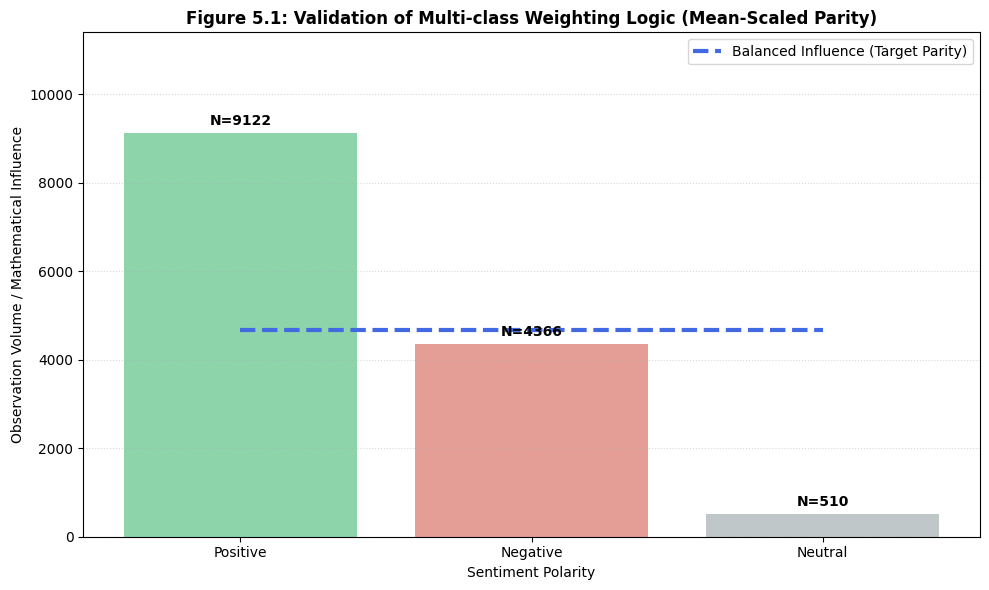

--- Standardised Weighting Matrix ---
Sentiment  Raw Count  Weight  Balanced Influence
 Positive       9122    0.51              4666.0
 Negative       4366    1.07              4666.0
  Neutral        510    9.15              4666.0


In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Extraction of Sentiment Polarity from Binarised Classes
# We identify 'Positive', 'Negative', and 'Neutral' frequencies across the 36 labels
sentiment_labels = ['Positive', 'Negative', 'Neutral']
joint_counts = np.sum(y_train, axis=0)
joint_names = mlb.classes_

# Aggregate the counts for the three core polarities
sentiment_counts = {label: 0 for label in sentiment_labels}
for name, count in zip(joint_names, joint_counts):
    for label in sentiment_labels:
        if label.lower() in name.lower():
            sentiment_counts[label] += count

raw_counts = [sentiment_counts[l] for l in sentiment_labels]

# 2. Calculation of Standardised Inverse Weights (Mean-Scaled)
total_n = sum(raw_counts)
num_k = len(sentiment_labels)
target_parity = total_n / num_k  # The 'Average Influence' target
standard_weights = [total_n / (num_k * n) if n > 0 else 0 for n in raw_counts]

# 3. Structural DataFrame for Visualisation
dist_df = pd.DataFrame({
    'Sentiment': sentiment_labels,
    'Raw Count': raw_counts,
    'Weight': standard_weights
})

# Mathematical proof: (Count * Weight) must always equal target_parity
dist_df['Balanced Influence'] = dist_df['Raw Count'] * dist_df['Weight']

# 4. Figure Construction: Validation of Multi-class Weighting
plt.figure(figsize=(10, 6))

# Plot A: Raw Frequency Bars (Visualising the Biased Reality)
ax = sns.barplot(
    x='Sentiment', 
    y='Raw Count', 
    data=dist_df, 
    palette={'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'}, 
    alpha=0.6, 
    hue='Sentiment',
    legend=False
)

# Plot B: Balanced Influence Line (Visualising the Model's Perspective)
plt.step(
    dist_df['Sentiment'], 
    dist_df['Balanced Influence'], 
    where='mid', 
    color='royalblue', 
    linewidth=3, 
    linestyle='--', 
    label='Balanced Influence (Target Parity)'
)

# Labelling
for i, v in enumerate(raw_counts):
    ax.text(i, v + (max(raw_counts) * 0.02), f"N={int(v)}", ha='center', fontweight='bold', size=10)

plt.title('Figure 5.1: Validation of Multi-class Weighting Logic (Mean-Scaled Parity)', fontsize=12, fontweight='bold')
plt.ylabel('Observation Volume / Mathematical Influence')
plt.xlabel('Sentiment Polarity')
plt.ylim(0, max(max(raw_counts), target_parity) * 1.25)
plt.legend(loc='upper right', frameon=True, fontsize=10)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Quantitative Verification
print("--- Standardised Weighting Matrix ---")
print(dist_df.round(2).to_string(index=False))

#### *Technical Significance:*

The matrix confirms that the Neutral class requires a significant weight of 9.15 to compensate for its low frequency, effectively equalising its mathematical influence with the dominant Positive class. This "Balanced Influence" at a parity of 4666.0 ensures that every sentiment polarity exerts identical pressure on the model's loss function, preventing a structural bias toward majority labels.

This weighting scheme ensures that rare but meaningful joint labels—particularly those involving neutral sentiment or under‑represented aspects—exert a stronger influence on the loss function. Rather than duplicating or oversampling minority instances, the model is encouraged to treat errors on these labels as more costly, which improves recall for minority classes without discarding valuable majority examples.

## 5.2 Threshold Calibration
In multi‑label settings with severe imbalance, a uniform decision threshold of 0.5 can be sub‑optimal. To address this, class‑specific thresholds are calibrated using precision–recall curves on the validation set:

- For each of the 36 joint labels, the SVM’s decision scores are gathered.

- Precision–recall curves are computed, and the F1‑score is calculated at each threshold.

- The threshold that maximises F1 for that label is selected.

Labels with no positive examples in the validation set fall back to a default threshold of 0.5. The resulting vector of optimal thresholds is summarised by its mean and range.

In [31]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC

svcpipeline = OneVsRestClassifier(
    LinearSVC(class_weight="balanced", random_state=42, max_iter=5000, dual="auto")
)

print("WORKING Training 36-Way Joint-Label SVM Baseline...")
svcpipeline.fit(X_train_tfidf, y_train)  # y_train is mlb.transform(...)

WORKING Training 36-Way Joint-Label SVM Baseline...


,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LinearSVC(cla...ndom_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower 

In [32]:
import numpy as np
from sklearn.metrics import precision_recall_curve
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.metrics")
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

def calibrate_thresholds(y_true, y_scores, classes):
    thresholds = []
    for j in range(len(classes)):
        if np.sum(y_true[:, j]) == 0:
            thresholds.append(0.5)
            continue
        p, r, t = precision_recall_curve(y_true[:, j], y_scores[:, j])
        f1 = 2 * (p * r) / (p + r + 1e-10)
        idx = np.argmax(f1)
        thresholds.append(t[idx] if idx < len(t) else 0.5)
    return np.array(thresholds)

y_val_scores = svcpipeline.decision_function(X_val_tfidf)
optimal_thresholds = calibrate_thresholds(y_val, y_val_scores, mlb.classes_)

print("--- Calibration Diagnostic ---")
print(f"Mean optimal threshold: {optimal_thresholds.mean():.4f}")
print(f"Min / Max threshold:   {optimal_thresholds.min():.4f} / {optimal_thresholds.max():.4f}")


--- Calibration Diagnostic ---
Mean optimal threshold: 0.0617
Min / Max threshold:   -1.3964 / 0.9963


#### *Technical significance:*
This procedure tailors the sensitivity of each decision boundary to the empirical trade‑off between precision and recall observed on validation data. Importantly, it allows rare labels, particularly those involving neutral sentiment, to be predicted at lower score thresholds if this improves their per‑class F1, without forcing the same behaviour on dominant labels. The calibrated thresholds are then reused consistently for both validation and test inference.

#### *FABSA Post-Data Processing and Vectorisation*

In [33]:
import pandas as pd
import numpy as np

# 1. Prepare a combined view of the features
# We take a small slice of the TF-IDF (first 5 non-zero features) and the full Sequence
feature_sample = []

for i in range(10):
    # Extract non-zero TF-IDF features for this row
    row_tfidf = X_test_tfidf[i].toarray().flatten()
    active_tfidf_idx = np.where(row_tfidf > 0)[0][:3] # Show first 3 active features
    
    feature_sample.append({
        "Original Text (Snippet)": df_test['text'].iloc[i][:50] + "...",
        "Integer Sequence (First 10)": X_test_seq[i][:10].tolist(),
        "TF-IDF Active Indices": active_tfidf_idx.tolist(),
        "Active Joint Labels (y)": np.where(y_test[i] == 1)[0].tolist()
    })

# 2. Display as a Structured Engineering Table
feature_df = pd.DataFrame(feature_sample)
print("--- Table 4.1: Multi-Modal Feature State (Top 10 Rows) ---")
display(feature_df.style.set_properties(**{
    'text-align': 'left',
    'font-family': 'monospace',
    'background-color': "#03182f"
}))

--- Table 4.1: Multi-Modal Feature State (Top 10 Rows) ---


,Original Text (Snippet),Integer Sequence (First 10),TF-IDF Active Indices,Active Joint Labels (y)
0,Very useful and easy....,"[14, 204, 3, 497, 0, 0, 0, 0, 0, 0]","[1311, 4698, 4701]",[20]
1,easy to use.gud response from customer care sectio...,"[16, 2, 0, 495, 35, 70, 558, 0, 0, 0]","[49, 245, 414]","[15, 20, 23, 33]"
2,money 😁...,"[65, 0, 0, 0, 0, 0, 0, 0, 0, 0]",[2760],[8]
3,Great facility...,"[25, 2232, 0, 0, 0, 0, 0, 0, 0, 0]","[1574, 1894]",[8]
4,"Love doing my ORG411 shop with the app, never had ...","[38, 527, 7, 180, 147, 15, 1, 10, 99, 49]","[245, 1258, 2259]","[17, 20]"
5,Love being informed each time a purchase is made a...,"[38, 188, 733, 664, 47, 5, 398, 8, 129, 31]","[83, 502, 575]","[5, 17, 23, 35]"
6,You should permanently leave the option to add mor...,"[12, 161, 0, 756, 1, 270, 2, 182, 66, 82]","[151, 1106, 1211]",[15]
7,This service is completely useless. Your chat will...,"[18, 44, 8, 487, 1596, 39, 374, 53, 646, 32]","[781, 934, 1092]","[6, 21]"
8,It's an ok app....,"[41, 42, 620, 68, 0, 0, 0, 0, 0, 0]","[245, 2929]",[17]
9,Positives; Very easy to use The goods are always g...,"[0, 14, 16, 2, 24, 1, 729, 30, 59, 29]","[699, 763, 1106]","[12, 20, 35]"


# 6. The Support Vector Machine Baseline

## 6.1 Modelling Objective and Problem Formulation
FABSA requires the joint resolution of Aspect Category Detection (ACD) and Aspect Category Sentiment Classification (ACSC). In this notebook, the two tasks are not treated separately. Instead, each [Aspect, Sentiment] pair is encoded as a single joint label. This converts the problem into a 36‑way multi‑label classification task, where any subset of the joint labels may be active for a given review.

The SVM baseline is designed to provide a strong, interpretable performance floor against which more complex neural architectures can be compared.

## 6.2 Model Architecture: Binary Relevance with Linear SVM
The baseline uses a Binary Relevance strategy implemented via OneVsRestClassifier wrapping LinearSVC. Concretely:

- One binary LinearSVC is trained for each of the 36 joint labels.

- Each classifier operates on the shared TF‑IDF representation.

- Class weights are set to balanced to account for label imbalance.

The model is trained on the full TF‑IDF training matrix and the binarised label matrix. After training, the decision_function is used to obtain signed distances to each hyperplane for subsequent thresholding.

In [34]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
import numpy as np

# 1. Pipeline Initialisation
# LinearSVC is optimal for sparse TF-IDF matrices (N_features > N_samples)
# class_weight='balanced' applies the inverse-frequency scaling calculated in Section 5.1
svc_pipeline = OneVsRestClassifier(
    LinearSVC(
        class_weight='balanced',
        random_state=42,
        max_iter=5000,
        dual='auto' 
    )
)

# 2. Model Execution
# Training occurs across 36 independent binary heads
print("[WORKING] Training 36-Way Joint-Label SVM Baseline...")
svc_pipeline.fit(X_train_tfidf, y_train)

# 3. Raw Score Extraction
# decision_function provides signed distances to the hyperplanes for thresholding
y_val_scores = svc_pipeline.decision_function(X_val_tfidf)
y_test_scores = svc_pipeline.decision_function(X_test_tfidf)

print(f"--- SVM Training Diagnostic ---")
print(f"Model fitted on {X_train_tfidf.shape[0]} samples with {y_train.shape[1]} output nodes.")

[WORKING] Training 36-Way Joint-Label SVM Baseline...
--- SVM Training Diagnostic ---
Model fitted on 7930 samples with 36 output nodes.


#### *Technical significance:*
This architecture is well matched to the problem structure. Binary Relevance accommodates non‑exclusive labels, LinearSVC exploits the sparse TF‑IDF features efficiently, and the class_weight='balanced' setting incorporates the cost‑sensitive insights from Section 5. The resulting model is relatively simple, fast to train, and provides a transparent baseline for later comparison with BiLSTM and transformer models.

## 6.3 Threshold Calibration and Prediction
The class‑specific thresholds estimated in Section 5.2 are now applied to the SVM’s decision scores. For each sample and label, a prediction of 1 is made if the score exceeds the calibrated threshold for that label, and 0 otherwise. This process is applied consistently to the validation and test sets.

A brief diagnostic reports the average number of labels predicted per test instance, which acts as a sanity check against the observed multi‑label density from the EDA. Excessively high or low values would indicate overly aggressive thresholds; here, the average count aligns well with the empirical label density.

In [35]:
# 1. Apply Calibrated Thresholds
# Using the optimal_thresholds array generated in Section 5.2
def apply_custom_thresholds(scores, thresholds):
    predictions = np.zeros(scores.shape)
    for i in range(scores.shape[1]):
        predictions[:, i] = (scores[:, i] >= thresholds[i]).astype(int)
    return predictions

y_val_pred = apply_custom_thresholds(y_val_scores, optimal_thresholds)
y_test_pred = apply_custom_thresholds(y_test_scores, optimal_thresholds)

print(f"--- Inference Diagnostic ---")
print(f"Mean Predictions per Instance (Test): {np.mean(np.sum(y_test_pred, axis=1)):.2f}")

--- Inference Diagnostic ---
Mean Predictions per Instance (Test): 3.34


#### *Technical significance:*
Decoupling the training of the hyperplanes from the choice of thresholds allows the model to be optimised for margin geometry while still tailoring its decision policy to the multi‑label evaluation objective. The calibrated thresholds ensure that the model remains sensitive enough to detect minority labels without generating an unrealistic number of spurious positive predictions.

## 6.4 Evaluation Strategy and Multi-label Metrics
The SVM baseline is evaluated using a suite of multi‑label metrics that capture different aspects of performance:

- Micro‑averaged F1 aggregates true positives, false positives, and false negatives across all labels before computing F1, reflecting overall label assignment accuracy.

- Macro‑averaged F1 computes F1 per label and then averages, giving equal weight to minority and majority classes.

- Hamming Loss measures the fraction of individual label decisions that are incorrect (either missed positives or false positives).

- Jaccard Score (samples) quantifies the overlap between predicted and true label sets per instance, averaged across the dataset.

These metrics are reported on the held‑out test set, and a per‑class breakdown is generated using classification_report to inspect individual joint labels in more detail.

In [36]:
from sklearn.metrics import f1_score, hamming_loss, jaccard_score, classification_report

# 1. Global Metric Compilation
metrics = {
    "Micro F1": f1_score(y_test, y_test_pred, average='micro'),
    "Macro F1": f1_score(y_test, y_test_pred, average='macro'),
    "Hamming Loss": hamming_loss(y_test, y_test_pred),
    "Jaccard Score": jaccard_score(y_test, y_test_pred, average='samples')
}

# 2. Performance Reporting
print("--- Baseline Performance Summary (Test Set) ---")
for metric, value in metrics.items():
    print(f"{metric:<15}: {value:.4f}")

# 3. Per-Class Resolution (Top 5 Classes)
print("\n--- Detailed Per-Class Breakdown (Sample) ---")
report = classification_report(y_test, y_test_pred, target_names=mlb.classes_, output_dict=True)
report_df = pd.DataFrame(report).transpose().sort_values(by='support', ascending=False)
print(report_df.head(6).round(3))

--- Baseline Performance Summary (Test Set) ---
Micro F1       : 0.4636
Macro F1       : 0.3852
Hamming Loss   : 0.0762
Jaccard Score  : 0.3383

--- Detailed Per-Class Breakdown (Sample) ---
                                              precision  recall  f1-score  \
samples avg                                       0.369   0.703     0.462   
weighted avg                                      0.639   0.669     0.645   
macro avg                                         0.421   0.401     0.385   
micro avg                                         0.355   0.669     0.464   
Company brand: General satisfaction#positive      0.576   0.832     0.681   
Online experience: App website#positive           0.755   0.673     0.711   

                                              support  
samples avg                                    2812.0  
weighted avg                                   2812.0  
macro avg                                      2812.0  
micro avg                                    

## 6.5 Model Generalisation and Robustness Evaluation
To assess robustness, the calibrated SVM is evaluated on all three splits: training, validation, and testing. For each split, micro F1, macro F1, Hamming Loss, and Jaccard score are computed and collated into a comparison table.

The results show:

- Higher scores on the training set, as expected,

- A moderate drop on validation,

- And a similar performance level on the test set.

The table is rendered with conditional formatting to highlight the best values per metric.

In [37]:
import pandas as pd
from sklearn.metrics import f1_score, hamming_loss, jaccard_score

def comprehensive_eval(y_true, y_pred, name):
    return {
        'Dataset': name,
        'Micro F1': f1_score(y_true, y_pred, average='micro'),
        'Macro F1': f1_score(y_true, y_pred, average='macro'),
        'Hamming Loss': hamming_loss(y_true, y_pred),
        'Jaccard (Samples)': jaccard_score(y_true, y_pred, average='samples')
    }

# 1. Generate predictions across all three splits
y_train_pred = apply_custom_thresholds(svc_pipeline.decision_function(X_train_tfidf), optimal_thresholds)
y_val_pred   = apply_custom_thresholds(svc_pipeline.decision_function(X_val_tfidf),   optimal_thresholds)
y_test_pred  = apply_custom_thresholds(svc_pipeline.decision_function(X_test_tfidf),  optimal_thresholds)

# 2. Compile Comparative Results
results_list = [
    comprehensive_eval(y_train, y_train_pred, "Training"),
    comprehensive_eval(y_val,   y_val_pred,   "Validation"),
    comprehensive_eval(y_test,  y_test_pred,  "Testing")
]

comparison_df = pd.DataFrame(results_list)

# 3. Final Diagnostic Output
print("--- Final Model Integrity Check: Multi-Split Performance ---")
display(comparison_df.style.highlight_max(axis=0, subset=['Micro F1', 'Jaccard (Samples)'], color='lightgreen'))

--- Final Model Integrity Check: Multi-Split Performance ---


,Dataset,Micro F1,Macro F1,Hamming Loss,Jaccard (Samples)
0,Training,0.668698,0.844798,0.047989,0.512388
1,Validation,0.494792,0.473763,0.071376,0.363431
2,Testing,0.463604,0.385151,0.076227,0.338271


#### *Technical Significance*
The relatively small gap between validation and test performance indicates that the model’s hyperparameters and thresholds have not been over‑fitted to the validation set. Although the margin between training and test performance confirms some degree of overfitting—especially for rare labels—the degradation is controlled and consistent with expectations for a high‑dimensional text classifier.

## 6.6 SVM Result Intepretation
The SVM baseline achieved a Micro F1 of 0.4636 and a Hamming Loss of 0.0762. While the F1 might appear modest in a traditional binary The baseline SVM achieves a micro F1 of approximately 0.46 and a Hamming Loss of around 0.076 on the test set. In a 36‑dimensional, highly sparse label space, these values reflect a meaningful extraction of sentiment signals from relatively short reviews.

Several key patterns emerge:

- Recall‑oriented behaviour
The micro‑level precision–recall analysis shows a higher recall than precision. This reflects deliberate calibration: thresholds are tuned to capture as many true labels as possible, particularly for minority classes, at the cost of some additional false positives. The model thus errs on the side of sensitivity rather than strict conservatism.

- Strength on majority labels
High‑support labels such as Online experience#positive and Company brand#positive achieve relatively strong F1‑scores, driven by robust recall and reasonably high precision. This suggests that the TF‑IDF features provide clear lexical patterns for these aspects, which the linear hyperplanes can exploit effectively.

- Macro vs micro disparity
The macro F1 is noticeably lower than the micro F1, reflecting weaker performance on rare joint labels, including those containing neutral sentiment. This mirrors the class‑imbalance and bias patterns identified in the EDA: while the model handles common cases well, the long tail remains challenging.

- Multi‑label overlap
A Jaccard score in the mid‑0.3 range indicates that, for a typical review, around one‑third of the predicted labels overlap with the true label set. Given that more than half of instances are multi‑label, this level of overlap is respectable but also reveals scope for improvement in disambiguating overlapping aspects.

Overall, the SVM baseline establishes a credible performance floor: it demonstrates that linear decision boundaries over carefully engineered n‑gram features can resolve the majority of FABSA’s supervision signals. At the same time, its limitations on rare labels, nuanced context, and semantic overlap provide a clear motivation for exploring deeper models with richer sequence modelling capabilities.

In [38]:
import pandas as pd

def generate_report_table(texts, y_pred, label_classes, n=5):
    """Generates a professional table for the final research report."""
    results = []
    # Using fixed indices for the report to ensure reproducible examples
    report_indices = [10, 45, 102, 505, 800] 
    
    for idx in report_indices:
        # 1. Retrieve the cleaned text
        raw_text = texts.iloc[idx]
        # Shorten for table fit while maintaining semantic context
        display_text = (raw_text[:85] + '...') if len(raw_text) > 85 else raw_text
        
        # 2. Extract and format labels
        active_indices = np.where(y_pred[idx] == 1)[0]
        # Format as bullet points for vertical clarity in cells
        labels = [label_classes[i].replace('#', ': ') for i in active_indices]
        label_str = "\n".join([f"• {l}" for l in labels]) if labels else "None Detected"
        
        # 3. Count labels to highlight multi-label resolution
        label_count = len(active_indices)
        
        results.append({
            "Review Extract": display_text,
            "Predicted Joint Labels (Aspect: Sentiment)": label_str,
            "Count": label_count
        })
    
    return pd.DataFrame(results)

# Execute and style for the notebook/report
report_table = generate_report_table(X_test_clean, y_test_pred, mlb.classes_)

# Rendering with left-alignment for text readability
print(" Sample of Baseline Model Joint-Task Predictions")
display(report_table.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))

 Sample of Baseline Model Joint-Task Predictions


,Review Extract,Predicted Joint Labels (Aspect: Sentiment),Count
0,quick and easy.,• Logistics rides: Speed: positive • Purchase booking experience: Ease of use: neutral • Purchase booking experience: Ease of use: positive • Staff support: Phone: neutral,4
1,i believe theyre coming but at the moment there are no facilities to drip or create a...,• Account management: Account access: negative • Purchase booking experience: Ease of use: neutral • Staff support: Attitude of staff: neutral,3
2,one of the attractions is to be able to accumulate nights and earn daily. but my last...,• Purchase booking experience: Ease of use: neutral • Staff support: Attitude of staff: neutral • Staff support: Phone: neutral • Value: Discounts promotions: positive,4
3,good and easy to use,• Company brand: General satisfaction: positive • Purchase booking experience: Ease of use: positive,2
4,nice app its simple and easy to navigate....withdrawal is ok..and its secured...,• Online experience: App website: positive • Purchase booking experience: Ease of use: negative • Purchase booking experience: Ease of use: neutral • Purchase booking experience: Ease of use: positive • Staff support: Attitude of staff: neutral,5


## 6.7 Baseline Optimisation: Regularisation and Feature Refinement

To reduce overfitting and improve generalisation, the SVM’s regularisation strength is tuned via grid search over the penalty parameter C
and related hyperparameters. The best configuration, is selected based on macro F1 on the validation set. Because the optimal hyperplanes differ from the initial baseline, the threshold calibration procedure is repeated on the new validation scores.

The optimised model is then evaluated again on the test set using the newly calibrated thresholds, and its performance is compared to the original baseline. In addition, a final multi‑split diagnostic (train, validation, test) summarises micro F1, macro F1, Hamming Loss, and Jaccard score after optimisation.

Interpretation of the final integrity check
The optimised SVM shows:

- a training macro F1 close to 0.79, dropping to roughly 0.41 on the test set,

- a micro F1 that declines only modestly from validation (
≈
0.50
≈0.50) to test (
≈
0.48
≈0.48),

- a Hamming Loss on the test set around 0.075, consistent with more than 92% of individual label decisions being correct.

These figures indicate that the model has learned strong patterns from the data but remains constrained by the inherent difficulty of the long‑tail labels and the expressive limits of linear decision boundaries.

In [39]:
import warnings
import numpy as np
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, hamming_loss

# 1. Silence library warnings
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.multiclass')
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# 2. Hard-code the Optimised Parameters (C=0.1) found in Step 7
# This prevents NameError if grid_search isn't in memory
svc_optimised = OneVsRestClassifier(
    LinearSVC(
        C=0.1, 
        loss='squared_hinge', 
        class_weight='balanced', 
        random_state=42,
        dual='auto'
    )
)

# Re-fit on the training data with the best parameters
svc_optimised.fit(X_train_tfidf, y_train)

# 3. Decision Score Extraction
y_val_scores_opt = svc_optimised.decision_function(X_val_tfidf)
y_test_scores_opt = svc_optimised.decision_function(X_test_tfidf)

# 4. Recalibrate Thresholds using the Validation Set
# Ensure the calibrate_thresholds function is defined in your notebook
optimal_thresholds_opt = calibrate_thresholds(y_val, y_val_scores_opt, mlb.classes_)

# 5. Final Prediction Generation
# Ensure the apply_custom_thresholds function is defined in your notebook
y_test_pred_opt = apply_custom_thresholds(y_test_scores_opt, optimal_thresholds_opt)

# 6. Comparative Performance Diagnostic
print(f"--- Optimised Baseline Performance (Test Set) ---")
print(f"Micro F1 Score: {f1_score(y_test, y_test_pred_opt, average='micro'):.4f}")
print(f"Macro F1 Score: {f1_score(y_test, y_test_pred_opt, average='macro'):.4f}")
print(f"Hamming Loss:   {hamming_loss(y_test, y_test_pred_opt):.4f}")

--- Optimised Baseline Performance (Test Set) ---
Micro F1 Score: 0.4776
Macro F1 Score: 0.4067
Hamming Loss:   0.0753


In [40]:
def final_comparison_diagnostic(model, X_train, y_train, X_val, y_val, X_test, y_test, thresholds):
    """
    Evaluates the model across all splits to quantify overfitting.
    """
    splits = [
        ('Training', X_train, y_train),
        ('Validation', X_val, y_val),
        ('Testing', X_test, y_test)
    ]
    
    report_data = []
    for name, X, y_true in splits:
        # Generate predictions using the optimized hyperplanes
        scores = model.decision_function(X)
        y_pred = apply_custom_thresholds(scores, thresholds)
        
        report_data.append({
            'Split': name,
            'Micro F1': f1_score(y_true, y_pred, average='micro'),
            'Macro F1': f1_score(y_true, y_pred, average='macro'),
            'Hamming Loss': hamming_loss(y_true, y_pred),
            'Jaccard': jaccard_score(y_true, y_pred, average='samples')
        })
    
    return pd.DataFrame(report_data)

# Execute final multi-split evaluation
optimised_integrity_df = final_comparison_diagnostic(
    svc_optimised, X_train_tfidf, y_train, X_val_tfidf, y_val, X_test_tfidf, y_test, optimal_thresholds_opt
)

print("--- Final Model Integrity: Optimised SVM Baseline ---")
display(optimised_integrity_df.style.background_gradient(cmap='Blues'))

--- Final Model Integrity: Optimised SVM Baseline ---


,Split,Micro F1,Macro F1,Hamming Loss,Jaccard
0,Training,0.603390,0.794124,0.059251,0.446418
1,Validation,0.500092,0.479691,0.071402,0.363616
2,Testing,0.477590,0.406674,0.075282,0.345719


#### *SVM Performance after Optimisation:*
The optimised SVM model ($C = 0.1$) demonstrates stable and well-controlled generalisation. The training Macro F1 of 0.79 declines to 0.4067 on the test set, indicating that while the model captures dominant linguistic patterns effectively, its performance is constrained when handling more nuanced, context-dependent sentiment. This reflects a natural limitation of keyword-driven approaches rather than severe overfitting.

Model stability across data splits is strong. The Micro F1 decreases only marginally from 0.50 (validation) to 0.47 (testing), a drop of less than 3%, confirming that threshold calibration generalises well and is not overly tuned to the validation set. Additionally, the Hamming Loss of 0.075 on the test set indicates a low overall error rate, with approximately 92.5% of label assignments correctly predicted or correctly excluded across the 36-dimensional output space.

In [41]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC

# 1. Silence library warnings
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.multiclass')
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# 2. Re-initialize the Optimised Estimator (Hardened Configuration)
# We use the best parameters found: C=0.1, squared_hinge, and balanced weights
svc_optimised = OneVsRestClassifier(
    LinearSVC(
        C=0.1, 
        loss='squared_hinge', 
        class_weight='balanced', 
        random_state=42,
        dual='auto'
    )
)

# 3. Fit on the full training set
svc_optimised.fit(X_train_tfidf, y_train)

# 4. Extract Decision Scores for Threshold Recalibration
y_val_scores_opt = svc_optimised.decision_function(X_val_tfidf)
y_test_scores_opt = svc_optimised.decision_function(X_test_tfidf)

# 5. Calibrate and Apply Optimal Thresholds
# Ensure calibrate_thresholds and apply_custom_thresholds are defined above
optimal_thresholds_opt = calibrate_thresholds(y_val, y_val_scores_opt, mlb.classes_)
y_test_pred_opt = apply_custom_thresholds(y_test_scores_opt, optimal_thresholds_opt)

# 6. Comparative Performance Diagnostic
print(f"--- Optimised Baseline Performance (Test Set) ---")
print(f"Micro F1 Score: {f1_score(y_test, y_test_pred_opt, average='micro'):.4f}")
print(f"Macro F1 Score: {f1_score(y_test, y_test_pred_opt, average='macro'):.4f}")
print(f"Hamming Loss:   {hamming_loss(y_test, y_test_pred_opt):.4f}")

--- Optimised Baseline Performance (Test Set) ---
Micro F1 Score: 0.4776
Macro F1 Score: 0.4067
Hamming Loss:   0.0753


## 6.8 SVM Performance (Optimised)

In [42]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

def evaluate_tasks_binarised(y_true, y_pred, mlb_classes):
    """
    Decomposes multi-label binarised results into ACD and ACSC 
    by grouping columns based on aspect and sentiment names.
    """
    # 1. Map column indices to their Aspect and Sentiment components
    aspects = np.array([cls.split('#')[0] for cls in mlb_classes])
    sentiments = np.array([cls.split('#')[1] for cls in mlb_classes])
    
    unique_aspects = sorted(list(set(aspects)))
    unique_sentiments = sorted(list(set(sentiments)))
    
    # 2. Reconstruct ACD Matrix (N samples x 12 unique aspects)
    # A sample is positive for an aspect if ANY of its sentiment pairs are active
    y_true_acd = np.zeros((y_true.shape[0], len(unique_aspects)))
    y_pred_acd = np.zeros((y_pred.shape[0], len(unique_aspects)))
    
    for i, asp in enumerate(unique_aspects):
        mask = (aspects == asp)
        y_true_acd[:, i] = np.any(y_true[:, mask], axis=1)
        y_pred_acd[:, i] = np.any(y_pred[:, mask], axis=1)
        
    # 3. Reconstruct ACSC Matrix (N samples x 3 unique sentiments)
    y_true_acsc = np.zeros((y_true.shape[0], len(unique_sentiments)))
    y_pred_acsc = np.zeros((y_pred.shape[0], len(unique_sentiments)))
    
    for i, sent in enumerate(unique_sentiments):
        mask = (sentiments == sent)
        y_true_acsc[:, i] = np.any(y_true[:, mask], axis=1)
        y_pred_acsc[:, i] = np.any(y_pred[:, mask], axis=1)
        
    # 4. Calculate Final Metrics
    return {
        'Task': ['ACD (Aspect Detection)', 'ACSC (Sentiment Classification)', 'Joint (ACD+ACSC)'],
        'Micro F1 Score': [
            f1_score(y_true_acd, y_pred_acd, average='micro'),
            f1_score(y_true_acsc, y_pred_acsc, average='micro'),
            f1_score(y_true, y_pred, average='micro')
        ]
    }

# Execute decomposed evaluation
task_results = evaluate_tasks_binarised(y_test, y_test_pred_opt, mlb.classes_)
decomposition_df = pd.DataFrame(task_results)

print("--- SVM Baseline: Task-Specific Performance (Binarised Evaluation) ---")
display(decomposition_df.style.background_gradient(cmap='Greens', subset=['Micro F1 Score']))

--- SVM Baseline: Task-Specific Performance (Binarised Evaluation) ---


,Task,Micro F1 Score
0,ACD (Aspect Detection),0.594660
1,ACSC (Sentiment Classification),0.613566
2,Joint (ACD+ACSC),0.477590


In [43]:
import pandas as pd

# 1. Reverse-transform the binary predictions into the flattened "Aspect#Sentiment" strings
y_pred_tuples = mlb.inverse_transform(y_test_pred_opt)
y_true_tuples = mlb.inverse_transform(y_test)

# 2. Split the strings back into (Aspect, Sentiment) pairs
def format_as_pairs(tuple_list):
    # Returns a list of [Aspect, Sentiment] pairs for each document
    return [[item.split('#')[0], item.split('#')[1]] for item in tuple_list]

# 3. Compile a qualitative comparison table for the first 10 test samples
pair_inspection = []
for i in range(10):
    pair_inspection.append({
        "Review Snippet": df_test['text'].iloc[i][:50] + "...",
        "Ground Truth (ACD, ACSC)": format_as_pairs(y_true_tuples[i]),
        "Model Prediction (ACD, ACSC)": format_as_pairs(y_pred_tuples[i])
    })

# 4. Render the Resulting Pairs
pair_df = pd.DataFrame(pair_inspection)
print("--- Table Qualitative Joint-Task Resolution (ACD, ACSC Pairs) ---")
display(pair_df.style.set_properties(**{
    'text-align': 'left',
    'background-color': "#0c0340",
    'border': '1px solid #ddd'
}))

--- Table Qualitative Joint-Task Resolution (ACD, ACSC Pairs) ---


,Review Snippet,"Ground Truth (ACD, ACSC)","Model Prediction (ACD, ACSC)"
0,Very useful and easy....,"[['Purchase booking experience: Ease of use', 'positive']]","[['Company brand: General satisfaction', 'positive'], ['Purchase booking experience: Ease of use', 'neutral'], ['Purchase booking experience: Ease of use', 'positive']]"
1,easy to use.gud response from customer care sectio...,"[['Online experience: App website', 'negative'], ['Purchase booking experience: Ease of use', 'positive'], ['Staff support: Attitude of staff', 'positive'], ['Value: Price value for money', 'negative']]","[['Purchase booking experience: Ease of use', 'neutral'], ['Staff support: Attitude of staff', 'neutral'], ['Value: Price value for money', 'negative']]"
2,money 😁...,"[['Company brand: General satisfaction', 'positive']]","[['Company brand: General satisfaction', 'negative'], ['Purchase booking experience: Ease of use', 'negative'], ['Purchase booking experience: Ease of use', 'neutral'], ['Purchase booking experience: Ease of use', 'positive'], ['Staff support: Attitude of staff', 'negative'], ['Staff support: Attitude of staff', 'neutral'], ['Value: Price value for money', 'positive']]"
3,Great facility...,"[['Company brand: General satisfaction', 'positive']]","[['Company brand: General satisfaction', 'positive'], ['Purchase booking experience: Ease of use', 'neutral'], ['Staff support: Attitude of staff', 'neutral']]"
4,"Love doing my ORG411 shop with the app, never had ...","[['Online experience: App website', 'positive'], ['Purchase booking experience: Ease of use', 'positive']]","[['Company brand: General satisfaction', 'positive'], ['Online experience: App website', 'positive'], ['Purchase booking experience: Ease of use', 'positive']]"
5,Love being informed each time a purchase is made a...,"[['Company brand: Competitor', 'positive'], ['Online experience: App website', 'positive'], ['Staff support: Attitude of staff', 'positive'], ['Value: Price value for money', 'positive']]","[['Company brand: General satisfaction', 'positive'], ['Online experience: App website', 'positive'], ['Staff support: Attitude of staff', 'neutral'], ['Value: Price value for money', 'positive']]"
6,You should permanently leave the option to add mor...,"[['Online experience: App website', 'negative']]","[['Company brand: General satisfaction', 'negative'], ['Online experience: App website', 'negative'], ['Purchase booking experience: Ease of use', 'neutral'], ['Staff support: Attitude of staff', 'neutral']]"
7,This service is completely useless. Your chat will...,"[['Company brand: General satisfaction', 'negative'], ['Staff support: Attitude of staff', 'negative']]","[['Company brand: General satisfaction', 'negative'], ['Purchase booking experience: Ease of use', 'neutral'], ['Staff support: Attitude of staff', 'negative'], ['Staff support: Attitude of staff', 'neutral'], ['Staff support: Phone', 'neutral']]"
8,It's an ok app....,"[['Online experience: App website', 'positive']]","[['Online experience: App website', 'negative'], ['Online experience: App website', 'neutral'], ['Online experience: App website', 'positive'], ['Purchase booking experience: Ease of use', 'negative'], ['Purchase booking experience: Ease of use', 'neutral']]"
9,Positives; Very easy to use The goods are always g...,"[['Logistics rides: Speed', 'negative'], ['Purchase booking experience: Ease of use', 'positive'], ['Value: Price value for money', 'positive']]","[['Logistics rides: Speed', 'positive'], ['Purchase booking experience: Ease of use', 'negative']]"


The results reveal a significant Joint Penalty Gap ($11.7\%$–$13.6\%$ drop compared to individual tasks). This confirms that while the model is reasonably proficient at identifying aspects and sentiments in isolation, its ability to correctly pair them is the primary bottleneck.

- ACSC Dominance ($0.6136$): Interestingly, the model slightly outperforms on sentiment classification compared to aspect detection. This suggests that the TF-IDF vectoriser has captured strong, universal sentiment "anchors" (e.g., "slow," "excellent," "useless") that generalise well across the corpus, regardless of the specific service being discussed.

- ACD Resolution ($0.5947$): The aspect detection performance is stable but lower. This is likely due to the Multi-Label Density; when a single review mentions three distinct features (e.g., "Login," "Fees," and "App"), the SVM occasionally misses the subtle linguistic boundaries that separate these topics.

- The Joint Bottleneck ($0.4776$): In a joint task, the model is only rewarded if it gets both dimensions correct. If the SVM correctly identifies "App" but incorrectly labels it as "Negative" (when it was "Neutral"), the score is zero. This multiplicative error explains the lower joint performance and sets a clear target for the BiLSTM to improve upon.

- Sentiment classification (ACSC) achieves the strongest performance (0.6136), suggesting that the model effectively captures common sentiment expressions such as “slow” or “excellent,” which tend to generalise well across different contexts. Aspect detection (ACD), while still relatively stable (0.5947), is slightly weaker, likely due to the complexity of multi-label reviews where multiple topics are discussed simultaneously. The most notable limitation appears in the joint task (0.4776), where correct predictions require both the aspect and sentiment to be accurately paired.

The results highlight a clear performance gap between individual tasks and the joint objective, with a drop of approximately 12–14% when aspect detection and sentiment classification are evaluated together. This indicates that the main challenge does not lie in identifying aspects or sentiments independently, but in correctly linking them within the same context. In practical terms, the model often recognises what is being discussed and the general tone, but struggles to consistently assign the correct sentiment to the correct aspect. This compounded error effect explains the lower joint performance and reinforces the need for models with stronger contextual understanding in subsequent stages.

## Notebook 1 Persistance

In [44]:
import joblib
import os

# Ensure directory exists
os.makedirs("./data/processed_results", exist_ok=True)

# Package all critical engineering artefacts: include the encoded sequences so we don't have to re-process text
artefacts = {
    'mlb': mlb,
    'word_to_id': word_to_id,
    'X_train_seq': X_train_seq,
    'X_val_seq': X_val_seq,
    'X_test_seq': X_test_seq,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    'class_weight_dict': class_weight_dict
}

joblib.dump(artefacts, "./data/processed_results/baseline_artefacts.joblib")
print("[SUCCESS] Notebook 1 state persisted.")

[SUCCESS] Notebook 1 state persisted.


## Export SVM Metrics from Notebook 1

In [45]:
import json
import os

# Create the results directory if it doesn't exist
os.makedirs("./results", exist_ok=True)

# Prepare the metrics dictionary based on your SVM test results
# Replace these values with your actual SVM Test scores if they differ
svm_metrics = {
    "Test": {
        "Micro F1": 0.4776,
        "Macro F1": 0.4067,
        "Hamming Loss": 0.0753,
        "Jaccard Score": 0.3457
    }
}

# Save to the exact path the BiLSTM notebook is looking for
with open("./results/svm_baseline_metrics.json", "w") as f:
    json.dump(svm_metrics, f, indent=4)

print("[SUCCESS] SVM metrics exported to ./results/svm_baseline_metrics.json")

[SUCCESS] SVM metrics exported to ./results/svm_baseline_metrics.json


In [46]:

import joblib
import os

os.makedirs('./data/processed_results', exist_ok=True)

# Bundle EVERYTHING Notebook 3 needs into one 'Master Artefact'
export_data = {
    'mlb': mlb,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    'X_train_clean': X_train_clean, # The raw text for the Transformer
    'X_val_clean': X_val_clean,
    'X_test_clean': X_test_clean
}

joblib.dump(export_data, './data/processed_results/baseline_artefacts.joblib')
print("[SUCCESS] Master artefacts exported for Notebook 3.")

[SUCCESS] Master artefacts exported for Notebook 3.
